In [40]:
import h5py
import pandas as pd
import numpy as np
from numpy.linalg import svd
from scipy import signal
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import umap
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import LeaveOneOut, GridSearchCV
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [41]:
sns.set_style("whitegrid")

In [42]:
def load_ssvep_data(filepath, stim_freqs):
    with h5py.File(filepath, "r") as f:
        data = f["y"][:]

    df = pd.DataFrame(
        data,
        columns=[
            "timestamp",
            "eeg_1",
            "eeg_2",
            "eeg_3",
            "eeg_4",
            "eeg_5",
            "eeg_6",
            "eeg_7",
            "eeg_8",
            "stimulus",
            "classifier_output",
        ],
    )

    # Extract trial onsets and assign labels
    trigger = df["stimulus"].to_numpy()
    onsets = np.where(np.diff(trigger) == 1)[0] + 1
    offsets = np.where(np.diff(trigger) == -1)[0] + 1
    labels = stim_freqs * 5

    # Add target label and trial number columns
    df["target Hz"] = 0  # 0 = rest/pause
    df["trial"] = 0  # 0 = not in a trial

    for trial_n, (on, off) in enumerate(zip(onsets, offsets)):
        df.loc[on : off - 1, "target Hz"] = labels[trial_n]
        df.loc[on : off - 1, "trial"] = trial_n + 1

    return df


def preprocess(df, eeg_cols, fs=256):
    df = df.copy()

    # Keep 8-50 Hz, remove everything else
    sos = signal.butter(4, [8, 50], btype="band", fs=fs, output="sos")
    # Apply filter to each EEG channel
    for col in eeg_cols:
        df[col] = signal.sosfiltfilt(sos, df[col].to_numpy())

    return df


def extract_features_psd(df, eeg_cols, stim_freqs, pre_sec=0.5, win_sec=6.85, fs=256):
    pre_samples = int(pre_sec * fs)
    win_samples = int(win_sec * fs)
    features_list = []

    for trial_num in range(1, df["trial"].max() + 1):
        trial_data = df[df["trial"] == trial_num]
        target = trial_data["target Hz"].iloc[0]
        eeg = trial_data[eeg_cols].to_numpy()

        segment = eeg[pre_samples : pre_samples + win_samples, :]
        if segment.shape[0] < win_samples:
            continue

        feat = {"trial": trial_num, "target": target}
        nperseg = min(1024, len(segment))

        for ch in range(8):
            ch_data = segment[:, ch]
            f, psd = signal.welch(
                ch_data, fs=fs, nperseg=nperseg, noverlap=nperseg // 2
            )

            for sf in stim_freqs:
                for h in range(1, 4):
                    freq = sf * h
                    if freq < fs / 2:
                        idx = np.argmin(np.abs(f - freq))
                        feat[f"ch{ch+1}_psd_{sf}Hz_h{h}"] = psd[idx]

                        neighbors = list(range(max(0, idx - 5), idx - 1)) + list(
                            range(idx + 2, min(len(psd), idx + 6))
                        )
                        if neighbors:
                            feat[f"ch{ch+1}_snr_{sf}Hz_h{h}"] = psd[idx] / (
                                np.mean(psd[neighbors]) + 1e-10
                            )

            powers = {}
            for sf in stim_freqs:
                idx = np.argmin(np.abs(f - sf))
                powers[sf] = psd[idx]
            total = sum(powers.values())
            for sf in stim_freqs:
                feat[f"ch{ch+1}_relpower_{sf}Hz"] = powers[sf] / (total + 1e-10)

            for band, (lo, hi) in {
                "theta": (4, 8),
                "alpha": (8, 13),
                "low_beta": (13, 20),
                "high_beta": (20, 30),
            }.items():
                mask = (f >= lo) & (f <= hi)
                feat[f"ch{ch+1}_{band}"] = np.mean(psd[mask])

            feat[f"ch{ch+1}_var"] = np.var(ch_data)

        features_list.append(feat)

    return pd.DataFrame(features_list)


def create_reference(freq, fs, n_samples, n_harmonics=3):
    t = np.arange(n_samples) / fs
    ref = []
    for h in range(1, n_harmonics + 1):
        ref.append(np.sin(2 * np.pi * h * freq * t))
        ref.append(np.cos(2 * np.pi * h * freq * t))

    return np.stack(ref, axis=1)


def cca_score(eeg, ref):
    x = eeg - eeg.mean(axis=0, keepdims=True)
    y = ref - ref.mean(axis=0, keepdims=True)
    ux, sx, _ = svd(x, full_matrices=False)
    uy, sy, _ = svd(y, full_matrices=False)
    tol_x = max(x.shape) * np.finfo(float).eps * sx[0]
    tol_y = max(y.shape) * np.finfo(float).eps * sy[0]
    qx = ux[:, : int(np.sum(sx > tol_x))]
    qy = uy[:, : int(np.sum(sy > tol_y))]
    corr = svd(qx.T @ qy, compute_uv=False)

    return float(np.clip(corr[0], 0.0, 1.0)) if corr.size else 0.0


def extract_features_cca(
    df, eeg_cols, stim_freqs, harmonics_list, pre_sec=0.5, win_sec=6.85, fs=256
):
    pre_samples = int(pre_sec * fs)
    win_samples = int(win_sec * fs)
    features_list = []

    for trial_num in range(1, df["trial"].max() + 1):
        trial_data = df[df["trial"] == trial_num]
        target = trial_data["target Hz"].iloc[0]
        eeg = trial_data[eeg_cols].to_numpy()

        segment = eeg[pre_samples : pre_samples + win_samples, :]
        if segment.shape[0] < win_samples:
            continue

        feat = {"trial": trial_num, "target": target}

        for n_h in harmonics_list:
            for sf in stim_freqs:
                ref = create_reference(sf, fs, segment.shape[0], n_harmonics=n_h)
                feat[f"cca_{sf}Hz_h{n_h}"] = cca_score(segment, ref)

        features_list.append(feat)

    return pd.DataFrame(features_list)


# def plot_psd_per_class(df, eeg_cols, stim_freqs, fs=256):
#     """PSD averaged across channels for each class."""
#     fig, axes = plt.subplots(len(stim_freqs), 1, figsize=(14, 3*len(stim_freqs)), sharex=True)

#     for i, target_freq in enumerate(stim_freqs):
#         trial_data = df[df['target Hz'] == target_freq][eeg_cols].to_numpy()

#         psds = []
#         for ch in range(8):
#             f, psd = signal.welch(trial_data[:, ch], fs=fs, nperseg=1024, noverlap=768)
#             psds.append(psd)
#         mean_psd = np.mean(psds, axis=0)

#         axes[i].plot(f, mean_psd, linewidth=1.5)

#         for sf in stim_freqs:
#             color = 'red' if sf == target_freq else 'gray'
#             lw = 2 if sf == target_freq else 0.8
#             axes[i].axvline(sf, color=color, linestyle='--', linewidth=lw, alpha=0.7)

#         axes[i].set_ylabel(f'{int(target_freq)} Hz')
#         axes[i].set_xlim([5, 50])

#     axes[-1].set_xlabel('Frequency (Hz)')
#     plt.suptitle('PSD per Class (all channels averaged)', fontsize=14)
#     plt.tight_layout()
#     plt.show()


def plot_psd_per_channel(df, eeg_cols, stim_freqs, title="PSD per Channel", fs=256):
    """PSD for each channel, overlaying all classes."""
    fig, axes = plt.subplots(2, 4, figsize=(18, 8))
    ch_names = ["PO7", "PO3", "POz", "PO4", "PO8", "O1", "Oz", "O2"]

    for ch_idx, col in enumerate(eeg_cols):
        ax = axes[ch_idx // 4, ch_idx % 4]

        for target_freq in stim_freqs:
            ch_data = df[df["target Hz"] == target_freq][col].to_numpy()
            f, psd = signal.welch(ch_data, fs=fs, nperseg=1024, noverlap=768)
            ax.plot(f, psd, label=f"{int(target_freq)} Hz")

        ax.set_xlim([5, 50])
        ax.set_title(f"{ch_names[ch_idx]}")

    # One shared legend for all subplots
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=10)

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.08)  # make room for the legend
    plt.show()


def plot_rest_vs_stimulus(df, eeg_cols, stim_freqs, title="Rest vs Stimulus", fs=256):
    """Compare PSD during rest vs stimulation."""
    rest_data = df[df["stimulus"] == 0][eeg_cols].to_numpy()
    stim_data = df[df["stimulus"] == 1][eeg_cols].to_numpy()

    rest_psds, stim_psds = [], []
    for ch in range(8):
        f, rest_psd = signal.welch(rest_data[:, ch], fs=fs, nperseg=1024, noverlap=768)
        f, stim_psd = signal.welch(stim_data[:, ch], fs=fs, nperseg=1024, noverlap=768)
        rest_psds.append(rest_psd)
        stim_psds.append(stim_psd)

    mean_rest = np.mean(rest_psds, axis=0)
    mean_stim = np.mean(stim_psds, axis=0)
    contrast = (mean_stim - mean_rest) / (mean_rest + 1e-10) * 100

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].semilogy(f, mean_rest, label="Rest", color="gray", linewidth=1.5)
    axes[0].semilogy(f, mean_stim, label="Stimulus", color="blue", linewidth=1.5)
    for sf in stim_freqs:
        axes[0].axvline(sf, color="red", linestyle="--", alpha=0.5)
    axes[0].set_xlim([5, 50])
    axes[0].set_xlabel("Frequency (Hz)")
    axes[0].set_ylabel("PSD")
    axes[0].set_title("Rest vs Stimulus")
    axes[0].legend()

    axes[1].plot(f, contrast, color="darkgreen", linewidth=1.5)
    axes[1].axhline(0, color="black", linewidth=0.5)
    for sf in stim_freqs:
        axes[1].axvline(sf, color="red", linestyle="--", alpha=0.5)
    axes[1].set_xlim([5, 50])
    axes[1].set_xlabel("Frequency (Hz)")
    axes[1].set_ylabel("% Change from Rest")
    axes[1].set_title("Evoked Response")

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


# def plot_snr_heatmap(feat_df, stim_freqs, title='SNR Heatmap'):
#     """SNR at fundamental frequency - diagonal = good separability."""
#     snr_matrix = np.zeros((len(stim_freqs), len(stim_freqs)))

#     for cls_idx, target in enumerate(stim_freqs):
#         for freq_idx, sf in enumerate(stim_freqs):
#             cols = [f'ch{ch+1}_snr_{sf}Hz_h1' for ch in range(8)]
#             available = [c for c in cols if c in feat_df.columns]
#             if available:
#                 snr_matrix[cls_idx, freq_idx] = feat_df[
#                     feat_df['target'] == target
#                 ][available].mean().mean()

#     fig, ax = plt.subplots(figsize=(7, 5))
#     sns.heatmap(
#         snr_matrix,
#         annot=True, fmt='.2f', annot_kws={'size': 11},
#         xticklabels=[f'{int(sf)} Hz' for sf in stim_freqs],
#         yticklabels=[f'Class {int(sf)} Hz' for sf in stim_freqs],
#         cmap='YlOrRd',
#         cbar_kws={'label': 'SNR'},
#         ax=ax,
#         square=True,
#     )
#     ax.set_xlabel('Stimulation Frequency')
#     ax.set_ylabel('Target Class')
#     ax.set_title(title)
#     plt.tight_layout()
#     plt.show()

# def plot_cca_heatmap(feat_df, stim_freqs, n_harmonics=3, title='CCA Heatmap'):
#     """CCA correlations - diagonal = good separability."""
#     corr_matrix = np.zeros((len(stim_freqs), len(stim_freqs)))

#     for cls_idx, target in enumerate(stim_freqs):
#         for freq_idx, sf in enumerate(stim_freqs):
#             col = f'cca_{sf}Hz_h{n_harmonics}'
#             if col in feat_df.columns:
#                 corr_matrix[cls_idx, freq_idx] = feat_df[
#                     feat_df['target'] == target
#                 ][col].mean()

#     fig, ax = plt.subplots(figsize=(7, 5))
#     sns.heatmap(
#         corr_matrix,
#         annot=True, fmt='.3f', annot_kws={'size': 11},
#         xticklabels=[f'{int(sf)} Hz' for sf in stim_freqs],
#         yticklabels=[f'Class {int(sf)} Hz' for sf in stim_freqs],
#         cmap='YlOrRd',
#         cbar_kws={'label': 'Correlation'},
#         ax=ax,
#         square=True,
#     )
#     ax.set_xlabel('Reference Frequency')
#     ax.set_ylabel('Target Class')
#     ax.set_title(title)
#     plt.tight_layout()
#     plt.show()


def plot_snr_heatmap_compare(feat_dfs, stim_freqs, titles, suptitle="SNR Comparison"):
    """Side by side SNR heatmaps, always 2 columns."""
    if not isinstance(feat_dfs, list):
        feat_dfs = [feat_dfs]
        titles = [titles]

    n = len(feat_dfs)
    n_cols = min(2, n)
    n_rows = (n + 1) // 2  # ceiling division

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 5 * n_rows))
    axes = np.array(axes).flatten()  # handles all cases: 1, 2, 3, 4+

    # Hide unused axes
    for i in range(n, len(axes)):
        axes[i].set_visible(False)

    for ax, feat_df, title in zip(axes, feat_dfs, titles):
        snr_matrix = np.zeros((len(stim_freqs), len(stim_freqs)))

        for cls_idx, target in enumerate(stim_freqs):
            for freq_idx, sf in enumerate(stim_freqs):
                cols = [f"ch{ch+1}_snr_{sf}Hz_h1" for ch in range(8)]
                available = [c for c in cols if c in feat_df.columns]
                if available:
                    snr_matrix[cls_idx, freq_idx] = (
                        feat_df[feat_df["target"] == target][available].mean().mean()
                    )

        sns.heatmap(
            snr_matrix,
            annot=True,
            fmt=".2f",
            annot_kws={"size": 11},
            xticklabels=[f"{int(sf)} Hz" for sf in stim_freqs],
            yticklabels=[f"Class {int(sf)} Hz" for sf in stim_freqs],
            cmap="YlOrRd",
            cbar_kws={"label": "SNR"},
            ax=ax,
            square=True,
        )
        ax.set_xlabel("Stimulation Frequency")
        ax.set_ylabel("Target Class")
        ax.set_title(title)

    plt.suptitle(suptitle, fontsize=14)
    plt.tight_layout()
    plt.show()


def plot_psd_per_class_compare(
    dfs, eeg_cols, stim_freqs, titles, suptitle="PSD per Class", fs=256
):
    """PSD averaged across channels for each class, side by side."""
    if not isinstance(dfs, list):
        dfs = [dfs]
        titles = [titles]

    n_cols = len(dfs)
    n_rows = len(stim_freqs)
    fig, axes = plt.subplots(
        n_rows, n_cols, figsize=(7 * n_cols, 3 * n_rows), sharex=True, sharey="row"
    )

    # Handle single column case
    if n_cols == 1:
        axes = axes.reshape(-1, 1)

    for col, (df, title) in enumerate(zip(dfs, titles)):
        for row, target_freq in enumerate(stim_freqs):
            ax = axes[row, col]
            trial_data = df[df["target Hz"] == target_freq][eeg_cols].to_numpy()

            psds = []
            for ch in range(len(eeg_cols)):
                f, psd = signal.welch(
                    trial_data[:, ch], fs=fs, nperseg=1024, noverlap=768
                )
                psds.append(psd)
            mean_psd = np.mean(psds, axis=0)

            ax.plot(f, mean_psd, linewidth=1.5)

            for sf in stim_freqs:
                color = "red" if sf == target_freq else "gray"
                lw = 2 if sf == target_freq else 0.8
                ax.axvline(sf, color=color, linestyle="--", linewidth=lw, alpha=0.7)

            ax.set_xlim([5, 50])

            if col == 0:
                ax.set_ylabel(f"{int(target_freq)} Hz")

        axes[0, col].set_title(title, fontsize=13)
        axes[-1, col].set_xlabel("Frequency (Hz)")

    plt.suptitle(suptitle, fontsize=14)
    plt.tight_layout()
    plt.show()


def plot_cca_heatmap_compare(
    feat_dfs, stim_freqs, titles, n_harmonics=3, suptitle="CCA Correlations"
):
    """CCA correlations - diagonal = good separability."""
    if not isinstance(feat_dfs, list):
        feat_dfs = [feat_dfs]
        titles = [titles]

    n = len(feat_dfs)
    n_cols = min(2, n)
    n_rows = (n + 1) // 2

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 5 * n_rows))
    axes = np.array(axes).flatten()

    for i in range(n, len(axes)):
        axes[i].set_visible(False)

    for ax, feat_df, title in zip(axes, feat_dfs, titles):
        corr_matrix = np.zeros((len(stim_freqs), len(stim_freqs)))

        for cls_idx, target in enumerate(stim_freqs):
            for freq_idx, sf in enumerate(stim_freqs):
                col = f"cca_{sf}Hz_h{n_harmonics}"
                if col in feat_df.columns:
                    corr_matrix[cls_idx, freq_idx] = feat_df[
                        feat_df["target"] == target
                    ][col].mean()

        sns.heatmap(
            corr_matrix,
            annot=True,
            fmt=".3f",
            annot_kws={"size": 11},
            xticklabels=[f"{int(sf)} Hz" for sf in stim_freqs],
            yticklabels=[f"Class {int(sf)} Hz" for sf in stim_freqs],
            cmap="YlOrRd",
            cbar_kws={"label": "Correlation"},
            ax=ax,
            square=True,
        )
        ax.set_xlabel("Reference Frequency")
        ax.set_ylabel("Target Class")
        ax.set_title(title)

    plt.suptitle(suptitle, fontsize=14)
    plt.tight_layout()
    plt.show()


def plot_feature_space(
    feat_dfs, stim_freqs, titles, method="pca", suptitle="Feature Space"
):
    """Visualize feature separability with dimensionality reduction."""
    if not isinstance(feat_dfs, list):
        feat_dfs = [feat_dfs]
        titles = [titles]

    n = len(feat_dfs)
    n_cols = min(2, n)
    n_rows = (n + 1) // 2

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 6 * n_rows))
    axes = np.array(axes).flatten()

    for i in range(n, len(axes)):
        axes[i].set_visible(False)

    for ax, feat_df, title in zip(axes, feat_dfs, titles):
        X = feat_df.drop(columns=["trial", "target"]).to_numpy()
        y = feat_df["target"].to_numpy()

        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        if method == "pca":
            reducer = PCA(n_components=2)
            coords = reducer.fit_transform(X_scaled)
            xlabel = f"PC 1 ({reducer.explained_variance_ratio_[0]:.1%})"
            ylabel = f"PC 2 ({reducer.explained_variance_ratio_[1]:.1%})"
        else:
            reducer = umap.UMAP(
                n_components=2, n_neighbors=5, min_dist=0.3, random_state=42
            )
            coords = reducer.fit_transform(X_scaled)
            xlabel = "UMAP 1"
            ylabel = "UMAP 2"

        plot_df = pd.DataFrame(
            {"x": coords[:, 0], "y": coords[:, 1], "Class": [f"{int(f)} Hz" for f in y]}
        )

        sns.scatterplot(
            data=plot_df,
            x="x",
            y="y",
            hue="Class",
            s=100,
            alpha=0.8,
            ax=ax,
            legend=False,
        )

        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_title(title)

    # Shared legend outside
    handles, labels = [], []
    for freq in stim_freqs:
        h = ax.scatter([], [], label=f"{int(freq)} Hz", s=80)
        handles.append(h)
    fig.legend(
        handles,
        [f"{int(f)} Hz" for f in stim_freqs],
        loc="lower center",
        ncol=len(stim_freqs),
        fontsize=10,
    )

    plt.suptitle(suptitle, fontsize=14)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.08)
    plt.show()


def plot_feature_space_sessions(
    feat_sessions_list,
    stim_freqs,
    titles,
    method="pca",
    suptitle="Cross-Session Feature Space",
):
    """Visualize sessions together per subject - color=class, shape=session."""
    if not isinstance(feat_sessions_list[0], list):
        feat_sessions_list = [feat_sessions_list]
        titles = [titles]
    if isinstance(titles, str):
        titles = [titles]

    n = len(feat_sessions_list)
    n_cols = min(2, n)
    n_rows = (n + 1) // 2

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 6 * n_rows))
    axes = np.array(axes).flatten()

    for i in range(n, len(axes)):
        axes[i].set_visible(False)

    session_markers = {1: "o", 2: "s", 3: "^", 4: "D"}
    freq_colors = {
        f: c for f, c in zip(stim_freqs, ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"])
    }

    for ax, sessions, title in zip(axes, feat_sessions_list, titles):
        combined_parts = []
        for sess_idx, feat_df in enumerate(sessions, start=1):
            part = feat_df.copy()
            part["session"] = sess_idx
            combined_parts.append(part)
        combined = pd.concat(combined_parts, ignore_index=True)

        X = combined.drop(columns=["trial", "target", "session"]).to_numpy()
        y = combined["target"].to_numpy()
        sess = combined["session"].to_numpy()

        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        if method == "pca":
            reducer = PCA(n_components=2)
            coords = reducer.fit_transform(X_scaled)
            xlabel = f"PC 1 ({reducer.explained_variance_ratio_[0]:.1%})"
            ylabel = f"PC 2 ({reducer.explained_variance_ratio_[1]:.1%})"
        else:
            n_samples = X_scaled.shape[0]
            reducer = umap.UMAP(
                n_components=2,
                n_neighbors=min(5, n_samples - 1),
                min_dist=0.3,
                random_state=42,
            )
            coords = reducer.fit_transform(X_scaled)
            xlabel = "UMAP 1"
            ylabel = "UMAP 2"

        for freq in stim_freqs:
            for s in sorted(combined["session"].unique()):
                mask = (y == freq) & (sess == s)
                ax.scatter(
                    coords[mask, 0],
                    coords[mask, 1],
                    color=freq_colors[freq],
                    marker=session_markers.get(s, "o"),
                    s=80,
                    alpha=0.7,
                )

        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_title(title)

    # Shared legend matching the colors
    legend_elements = []
    for freq in stim_freqs:
        legend_elements.append(
            plt.scatter([], [], color=freq_colors[freq], label=f"{int(freq)} Hz", s=80)
        )
    for s in range(1, len(feat_sessions_list[0]) + 1):
        legend_elements.append(
            plt.scatter(
                [],
                [],
                marker=session_markers[s],
                color="gray",
                label=f"Session {s}",
                s=80,
            )
        )

    fig.legend(
        handles=legend_elements,
        loc="lower center",
        ncol=len(stim_freqs) + len(feat_sessions_list[0]),
        fontsize=9,
    )

    plt.suptitle(suptitle, fontsize=14)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15)
    plt.show()

In [43]:
def extract_features_fbcca(
    df, eeg_cols, stim_freqs, pre_sec=0.5, win_sec=6.85, fs=256, n_harmonics=3
):
    """FBCCA feature extraction (Chen 2015).

    Filter bank: 5 sub-bands with progressively higher lower cutoffs.
    Applied on top of the already-bandpassed signal (8-50 Hz), so
    upper bound is capped at 50 Hz.

    Feature per frequency: Σ wₖ · rₖ²
    Weights: wₖ = (k+1)^(-1.25) + 0.25
    """
    from scipy.signal import butter, sosfiltfilt

    FILTER_BANK = [
        (8,  50),   # sub-band 1 — full passband
        (14, 50),   # sub-band 2 — 2nd harmonic and up
        (22, 50),   # sub-band 3
        (30, 50),   # sub-band 4
        (38, 50),   # sub-band 5 — high harmonics only
    ]
    weights = np.array([(k + 1) ** -1.25 + 0.25 for k in range(len(FILTER_BANK))])

    pre_samples = int(pre_sec * fs)
    win_samples = int(win_sec * fs)
    features_list = []

    for trial_num in range(1, df["trial"].max() + 1):
        trial_data = df[df["trial"] == trial_num]
        target = trial_data["target Hz"].iloc[0]
        eeg = trial_data[eeg_cols].to_numpy()

        segment = eeg[pre_samples : pre_samples + win_samples, :]
        if segment.shape[0] < win_samples:
            continue

        feat = {"trial": trial_num, "target": target}

        for sf in stim_freqs:
            ref = create_reference(sf, fs, segment.shape[0], n_harmonics=n_harmonics)
            weighted_score = 0.0
            for k, (lo, hi) in enumerate(FILTER_BANK):
                nyq = fs / 2.0
                sos = butter(4, [lo / nyq, hi / nyq], btype="band", output="sos")
                filtered = sosfiltfilt(sos, segment, axis=0)
                r = cca_score(filtered, ref)
                weighted_score += weights[k] * (r ** 2)
            feat[f"fbcca_{sf}Hz"] = weighted_score

        features_list.append(feat)

    return pd.DataFrame(features_list)


In [44]:
# Configurations

EEG_COLS = ["eeg_1", "eeg_2", "eeg_3", "eeg_4", "eeg_5", "eeg_6", "eeg_7", "eeg_8"]
STIM_FREQS = [9, 10, 12, 15]
FS = 256
PRE_SEC = 0.5  # Skip first 0.5 s after trigger onset
CCA_HARMONICS = [1, 2, 3, 4, 5]

In [45]:
# Load all four files
sub_1_sess_1 = preprocess(
    load_ssvep_data(
        "../data/raw/ssvep/subject_1_fvep_led_training_1.mat",
        stim_freqs=STIM_FREQS,
    ),
    eeg_cols=EEG_COLS,
    fs=FS,
)
sub_1_sess_2 = preprocess(
    load_ssvep_data(
        "../data/raw/ssvep/subject_1_fvep_led_training_2.mat",
        stim_freqs=STIM_FREQS,
    ),
    eeg_cols=EEG_COLS,
    fs=FS,
)
sub_2_sess_1 = preprocess(
    load_ssvep_data(
        "../data/raw/ssvep/subject_2_fvep_led_training_1.mat",
        stim_freqs=STIM_FREQS,
    ),
    eeg_cols=EEG_COLS,
    fs=FS,
)
sub_2_sess_2 = preprocess(
    load_ssvep_data(
        "../data/raw/ssvep/subject_2_fvep_led_training_2.mat",
        stim_freqs=STIM_FREQS,
    ),
    eeg_cols=EEG_COLS,
    fs=FS,
)

In [46]:
# Get PSD and CCA features

sub_1_sess_1_psd_feat = extract_features_psd(
    sub_1_sess_1,
    eeg_cols=EEG_COLS,
    stim_freqs=STIM_FREQS,
    pre_sec=PRE_SEC,
    win_sec=6.85,
    fs=FS,
)
sub_1_sess_2_psd_feat = extract_features_psd(
    sub_1_sess_2,
    eeg_cols=EEG_COLS,
    stim_freqs=STIM_FREQS,
    pre_sec=PRE_SEC,
    win_sec=6.85,
    fs=FS,
)
sub_2_sess_1_psd_feat = extract_features_psd(
    sub_2_sess_1,
    eeg_cols=EEG_COLS,
    stim_freqs=STIM_FREQS,
    pre_sec=PRE_SEC,
    win_sec=6.85,
    fs=FS,
)
sub_2_sess_2_psd_feat = extract_features_psd(
    sub_2_sess_2,
    eeg_cols=EEG_COLS,
    stim_freqs=STIM_FREQS,
    pre_sec=PRE_SEC,
    win_sec=6.85,
    fs=FS,
)


sub_1_sess_1_cca_feat = extract_features_cca(
    sub_1_sess_1,
    eeg_cols=EEG_COLS,
    stim_freqs=STIM_FREQS,
    pre_sec=PRE_SEC,
    win_sec=6.85,
    harmonics_list=CCA_HARMONICS,
    fs=FS,
)
sub_1_sess_2_cca_feat = extract_features_cca(
    sub_1_sess_2,
    eeg_cols=EEG_COLS,
    stim_freqs=STIM_FREQS,
    pre_sec=PRE_SEC,
    win_sec=6.85,
    harmonics_list=CCA_HARMONICS,
    fs=FS,
)
sub_2_sess_1_cca_feat = extract_features_cca(
    sub_2_sess_1,
    eeg_cols=EEG_COLS,
    stim_freqs=STIM_FREQS,
    pre_sec=PRE_SEC,
    win_sec=6.85,
    harmonics_list=CCA_HARMONICS,
    fs=FS,
)
sub_2_sess_2_cca_feat = extract_features_cca(
    sub_2_sess_2,
    eeg_cols=EEG_COLS,
    stim_freqs=STIM_FREQS,
    pre_sec=PRE_SEC,
    win_sec=6.85,
    harmonics_list=CCA_HARMONICS,
    fs=FS,
)

/var/folders/jg/80bh3f0d7k3bgnpkk8b9bxc80000gn/T/ipykernel_5950/1074189233.py:132: RuntimeWarning: divide by zero encountered in matmul
  corr = svd(qx.T @ qy, compute_uv=False)
/var/folders/jg/80bh3f0d7k3bgnpkk8b9bxc80000gn/T/ipykernel_5950/1074189233.py:132: RuntimeWarning: overflow encountered in matmul
  corr = svd(qx.T @ qy, compute_uv=False)
/var/folders/jg/80bh3f0d7k3bgnpkk8b9bxc80000gn/T/ipykernel_5950/1074189233.py:132: RuntimeWarning: invalid value encountered in matmul
  corr = svd(qx.T @ qy, compute_uv=False)
/var/folders/jg/80bh3f0d7k3bgnpkk8b9bxc80000gn/T/ipykernel_5950/1074189233.py:132: RuntimeWarning: divide by zero encountered in matmul
  corr = svd(qx.T @ qy, compute_uv=False)
/var/folders/jg/80bh3f0d7k3bgnpkk8b9bxc80000gn/T/ipykernel_5950/1074189233.py:132: RuntimeWarning: overflow encountered in matmul
  corr = svd(qx.T @ qy, compute_uv=False)
/var/folders/jg/80bh3f0d7k3bgnpkk8b9bxc80000gn/T/ipykernel_5950/1074189233.py:132: RuntimeWarning: invalid value encountere

In [47]:
# ── FBCCA feature extraction ──────────────────────────────────────────────
sub_1_sess_1_fbcca_feat = extract_features_fbcca(
    sub_1_sess_1, eeg_cols=EEG_COLS, stim_freqs=STIM_FREQS,
    pre_sec=PRE_SEC, win_sec=6.85, fs=FS,
)
sub_1_sess_2_fbcca_feat = extract_features_fbcca(
    sub_1_sess_2, eeg_cols=EEG_COLS, stim_freqs=STIM_FREQS,
    pre_sec=PRE_SEC, win_sec=6.85, fs=FS,
)
sub_2_sess_1_fbcca_feat = extract_features_fbcca(
    sub_2_sess_1, eeg_cols=EEG_COLS, stim_freqs=STIM_FREQS,
    pre_sec=PRE_SEC, win_sec=6.85, fs=FS,
)
sub_2_sess_2_fbcca_feat = extract_features_fbcca(
    sub_2_sess_2, eeg_cols=EEG_COLS, stim_freqs=STIM_FREQS,
    pre_sec=PRE_SEC, win_sec=6.85, fs=FS,
)
print("FBCCA features ready:", sub_1_sess_1_fbcca_feat.shape, sub_2_sess_1_fbcca_feat.shape)


/var/folders/jg/80bh3f0d7k3bgnpkk8b9bxc80000gn/T/ipykernel_5950/1074189233.py:132: RuntimeWarning: divide by zero encountered in matmul
  corr = svd(qx.T @ qy, compute_uv=False)
/var/folders/jg/80bh3f0d7k3bgnpkk8b9bxc80000gn/T/ipykernel_5950/1074189233.py:132: RuntimeWarning: overflow encountered in matmul
  corr = svd(qx.T @ qy, compute_uv=False)
/var/folders/jg/80bh3f0d7k3bgnpkk8b9bxc80000gn/T/ipykernel_5950/1074189233.py:132: RuntimeWarning: invalid value encountered in matmul
  corr = svd(qx.T @ qy, compute_uv=False)
/var/folders/jg/80bh3f0d7k3bgnpkk8b9bxc80000gn/T/ipykernel_5950/1074189233.py:132: RuntimeWarning: divide by zero encountered in matmul
  corr = svd(qx.T @ qy, compute_uv=False)
/var/folders/jg/80bh3f0d7k3bgnpkk8b9bxc80000gn/T/ipykernel_5950/1074189233.py:132: RuntimeWarning: overflow encountered in matmul
  corr = svd(qx.T @ qy, compute_uv=False)
/var/folders/jg/80bh3f0d7k3bgnpkk8b9bxc80000gn/T/ipykernel_5950/1074189233.py:132: RuntimeWarning: invalid value encountere

FBCCA features ready: (20, 6) (20, 6)


/var/folders/jg/80bh3f0d7k3bgnpkk8b9bxc80000gn/T/ipykernel_5950/1074189233.py:132: RuntimeWarning: divide by zero encountered in matmul
  corr = svd(qx.T @ qy, compute_uv=False)
/var/folders/jg/80bh3f0d7k3bgnpkk8b9bxc80000gn/T/ipykernel_5950/1074189233.py:132: RuntimeWarning: overflow encountered in matmul
  corr = svd(qx.T @ qy, compute_uv=False)
/var/folders/jg/80bh3f0d7k3bgnpkk8b9bxc80000gn/T/ipykernel_5950/1074189233.py:132: RuntimeWarning: invalid value encountered in matmul
  corr = svd(qx.T @ qy, compute_uv=False)
/var/folders/jg/80bh3f0d7k3bgnpkk8b9bxc80000gn/T/ipykernel_5950/1074189233.py:132: RuntimeWarning: divide by zero encountered in matmul
  corr = svd(qx.T @ qy, compute_uv=False)
/var/folders/jg/80bh3f0d7k3bgnpkk8b9bxc80000gn/T/ipykernel_5950/1074189233.py:132: RuntimeWarning: overflow encountered in matmul
  corr = svd(qx.T @ qy, compute_uv=False)
/var/folders/jg/80bh3f0d7k3bgnpkk8b9bxc80000gn/T/ipykernel_5950/1074189233.py:132: RuntimeWarning: invalid value encountere

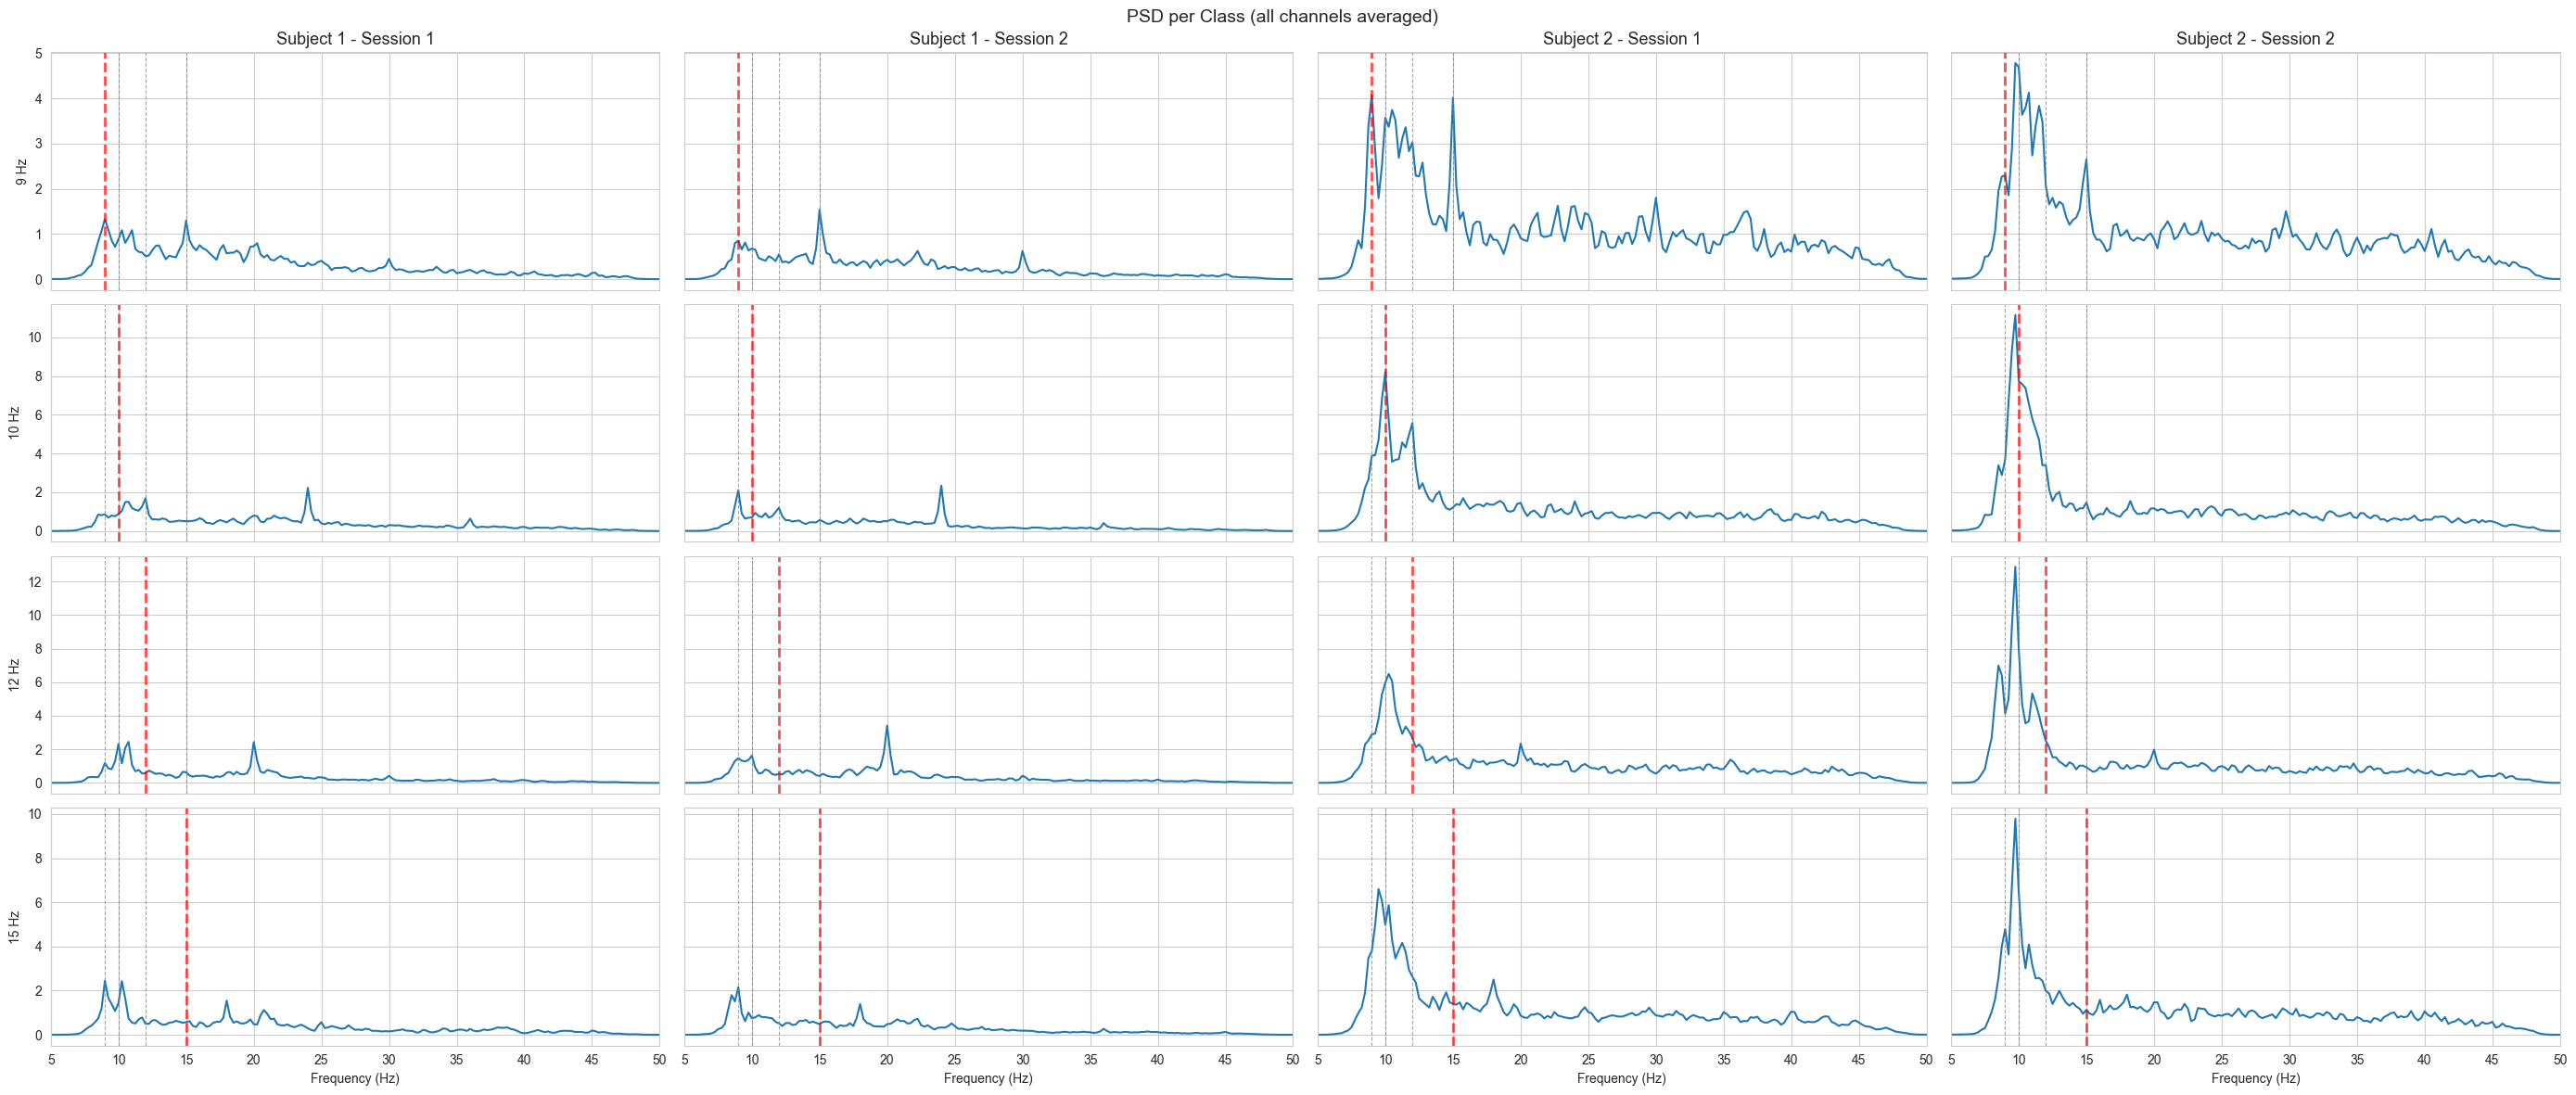

In [48]:
plot_psd_per_class_compare(
    dfs=[
        sub_1_sess_1,
        sub_1_sess_2,
        sub_2_sess_1,
        sub_2_sess_2,
    ],
    eeg_cols=EEG_COLS,
    stim_freqs=STIM_FREQS,
    titles=[
        "Subject 1 - Session 1",
        "Subject 1 - Session 2",
        "Subject 2 - Session 1",
        "Subject 2 - Session 2",
    ],
    suptitle="PSD per Class (all channels averaged)",
    fs=FS,
)

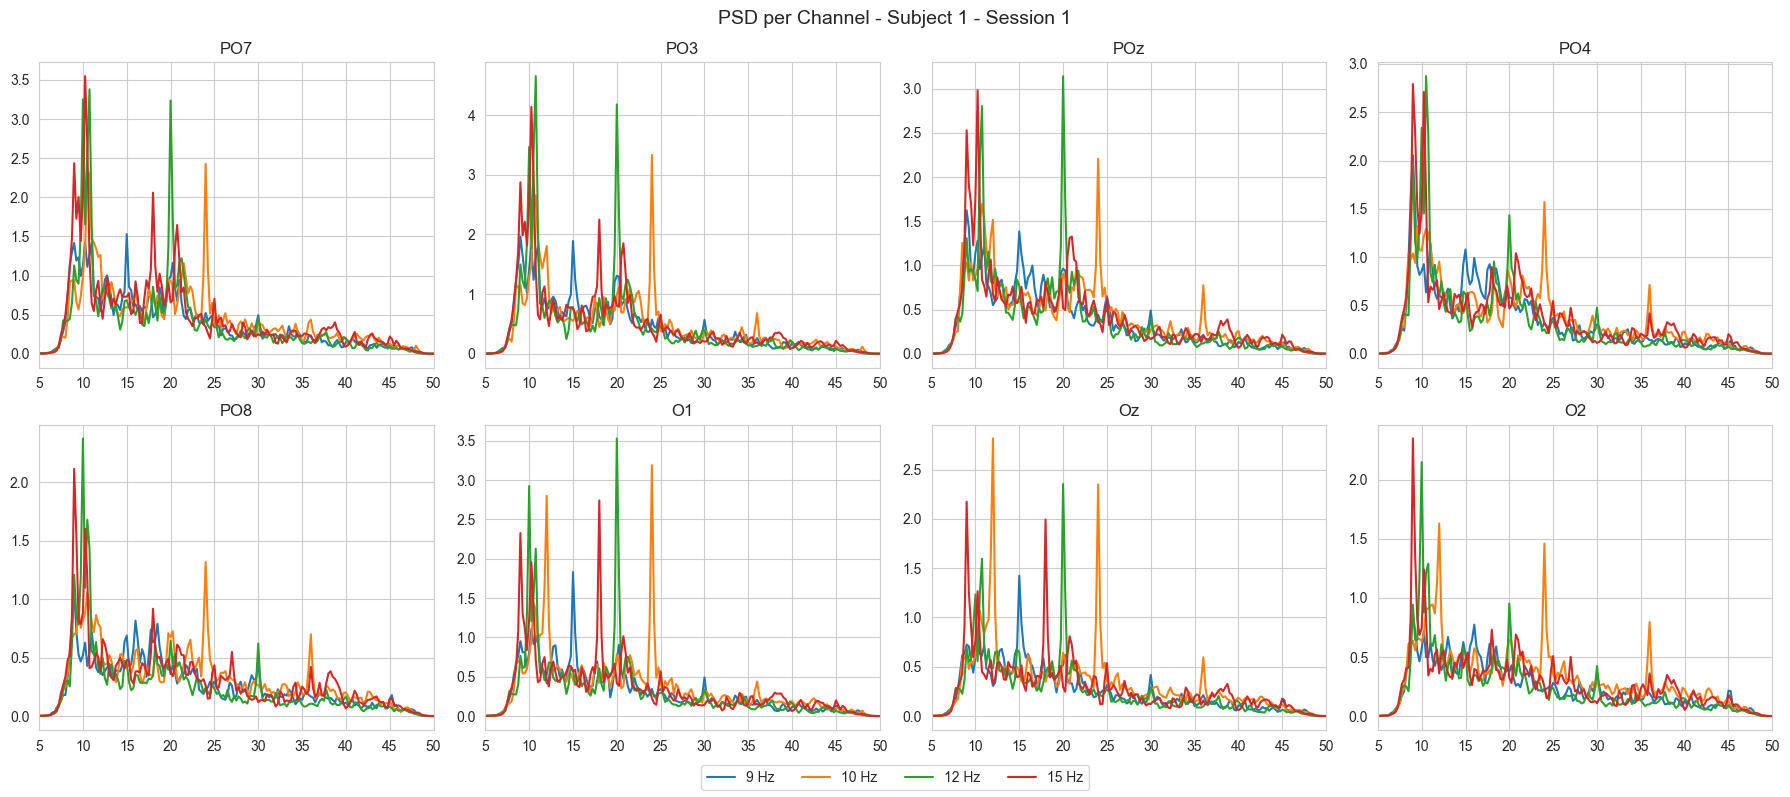

In [49]:
plot_psd_per_channel(
    sub_1_sess_1,
    eeg_cols=EEG_COLS,
    stim_freqs=STIM_FREQS,
    title="PSD per Channel - Subject 1 - Session 1",
    fs=FS,
)

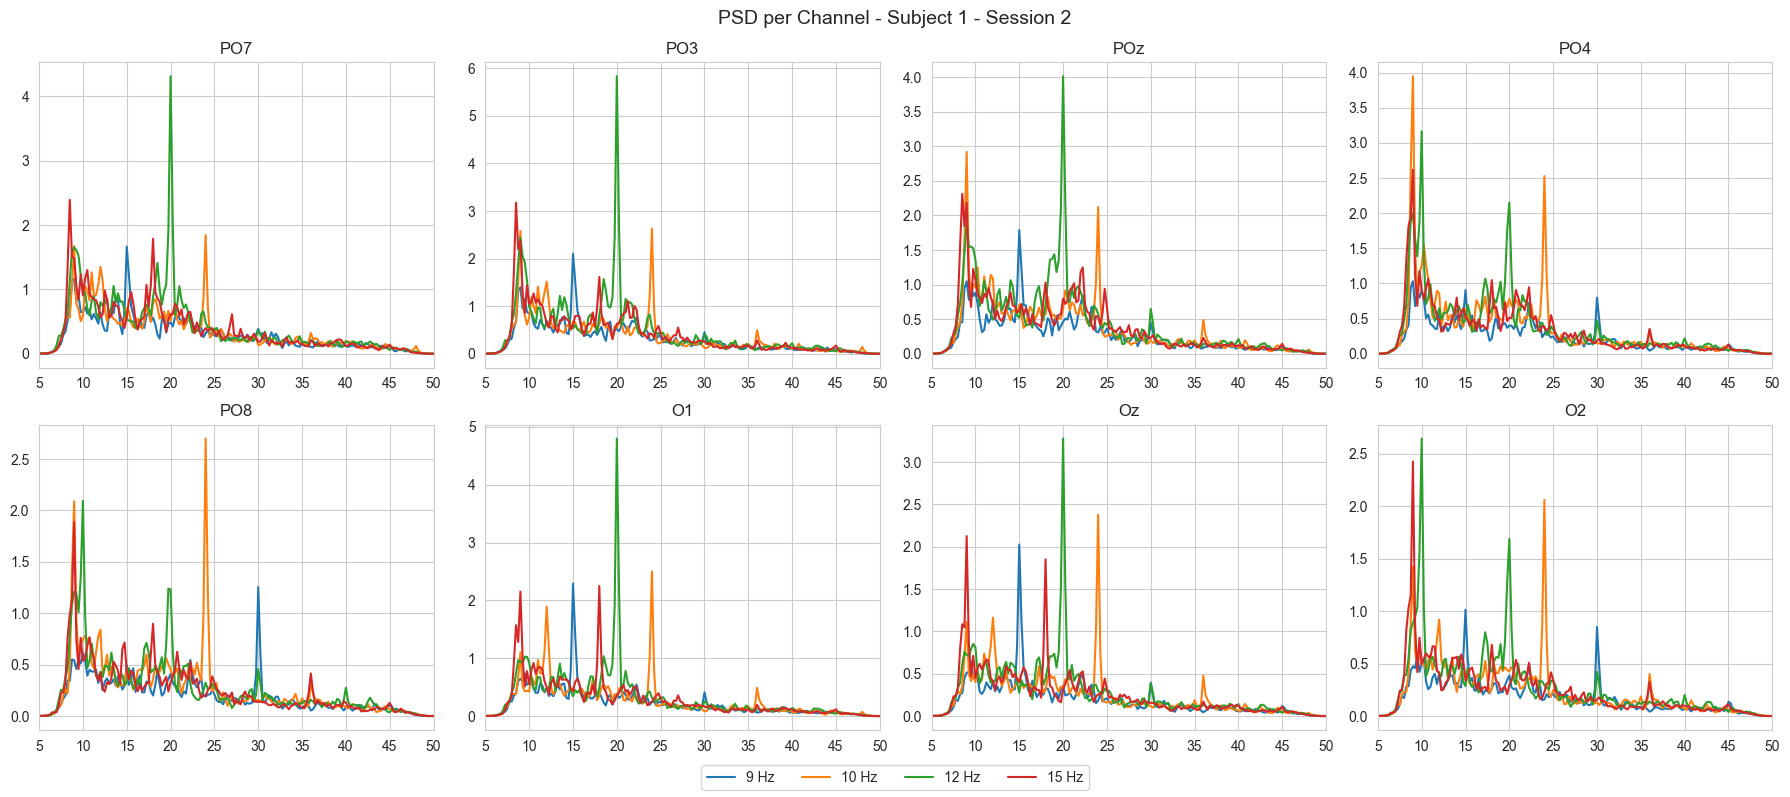

In [50]:
plot_psd_per_channel(
    sub_1_sess_2,
    eeg_cols=EEG_COLS,
    stim_freqs=STIM_FREQS,
    title="PSD per Channel - Subject 1 - Session 2",
    fs=FS,
)

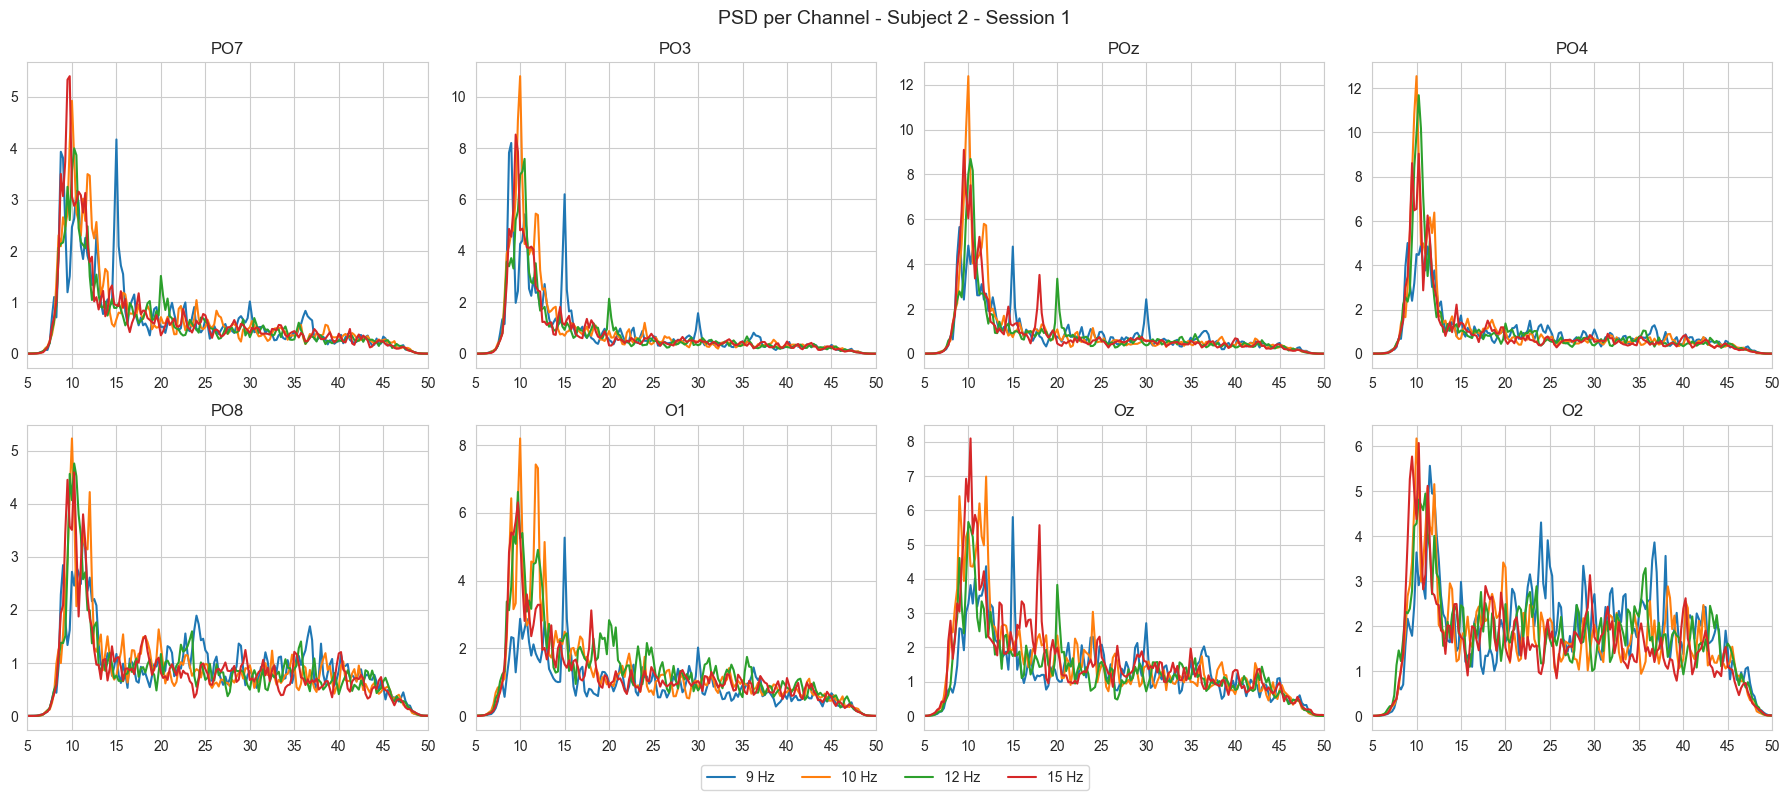

In [51]:
plot_psd_per_channel(
    sub_2_sess_1,
    eeg_cols=EEG_COLS,
    stim_freqs=STIM_FREQS,
    title="PSD per Channel - Subject 2 - Session 1",
    fs=FS,
)

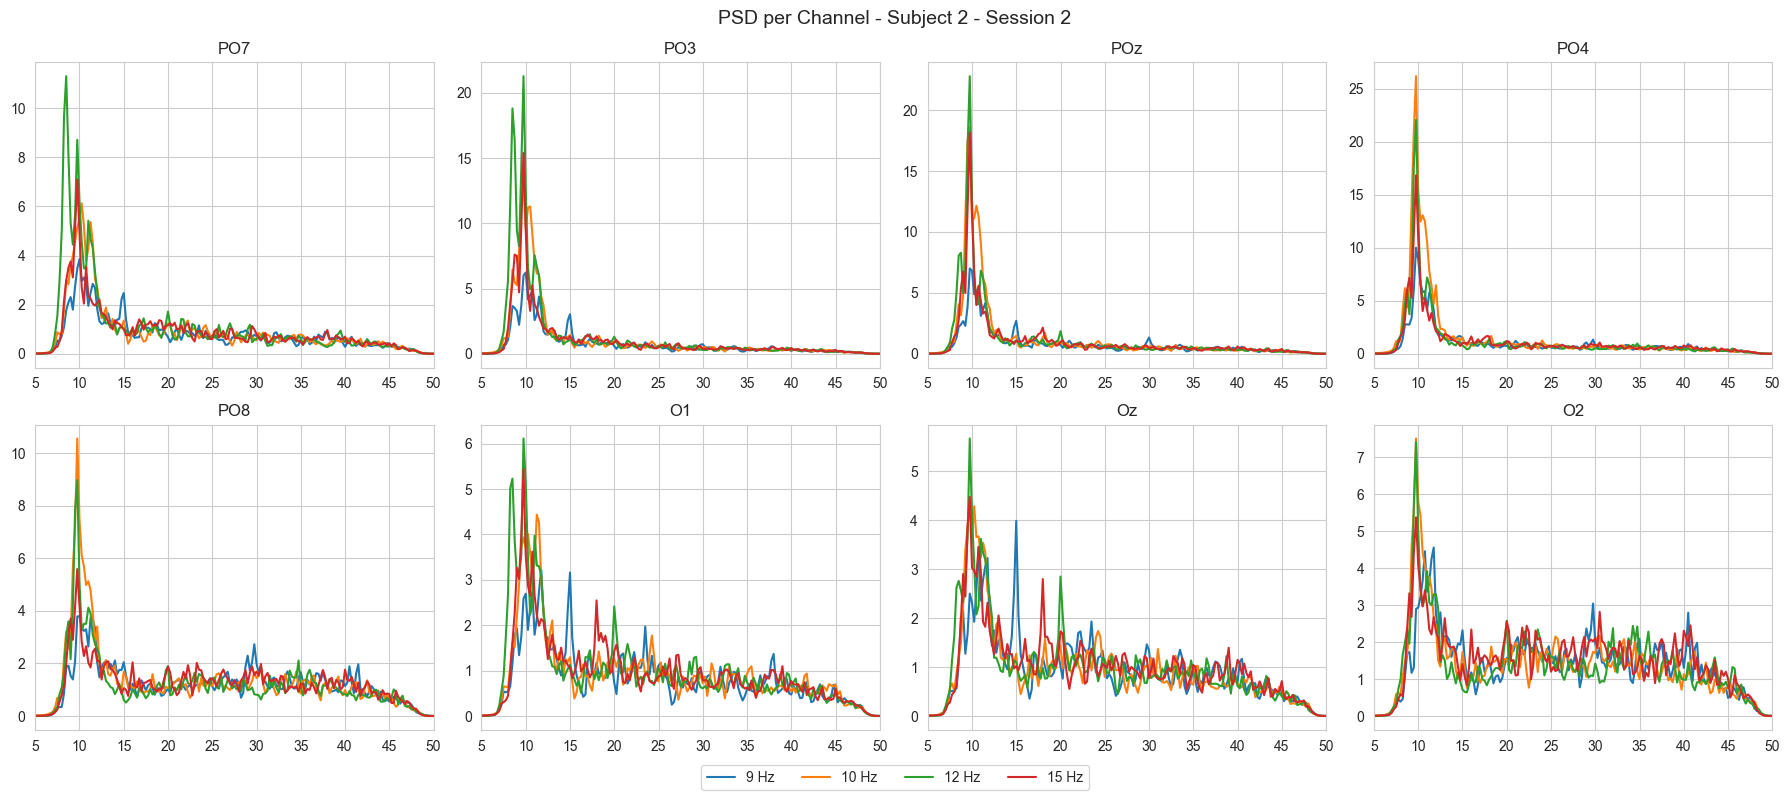

In [52]:
plot_psd_per_channel(
    sub_2_sess_2,
    eeg_cols=EEG_COLS,
    stim_freqs=STIM_FREQS,
    title="PSD per Channel - Subject 2 - Session 2",
    fs=FS,
)

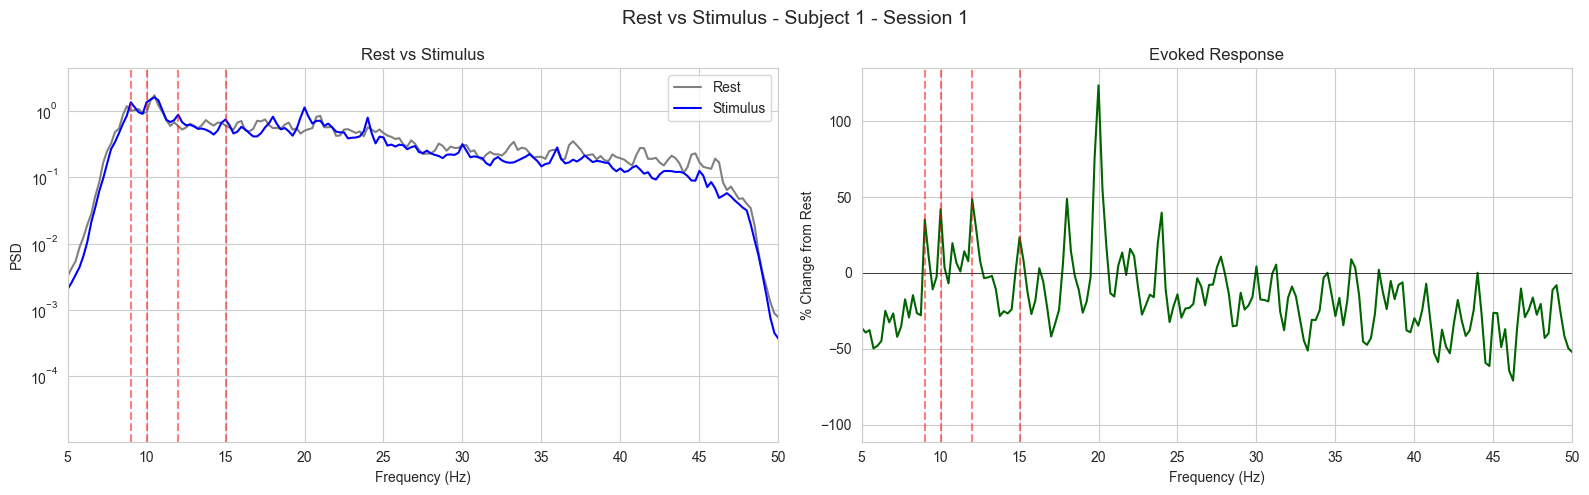

In [53]:
plot_rest_vs_stimulus(
    sub_1_sess_1,
    eeg_cols=EEG_COLS,
    stim_freqs=STIM_FREQS,
    title="Rest vs Stimulus - Subject 1 - Session 1",
    fs=FS,
)

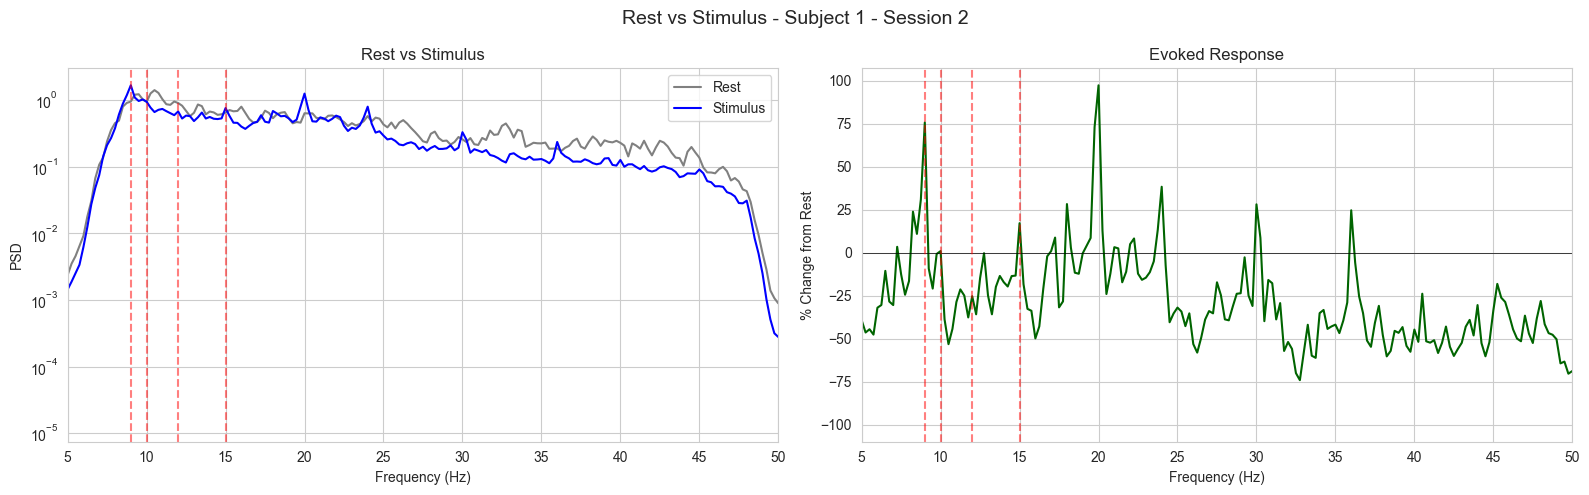

In [54]:
plot_rest_vs_stimulus(
    sub_1_sess_2,
    eeg_cols=EEG_COLS,
    stim_freqs=STIM_FREQS,
    title="Rest vs Stimulus - Subject 1 - Session 2",
    fs=FS,
)

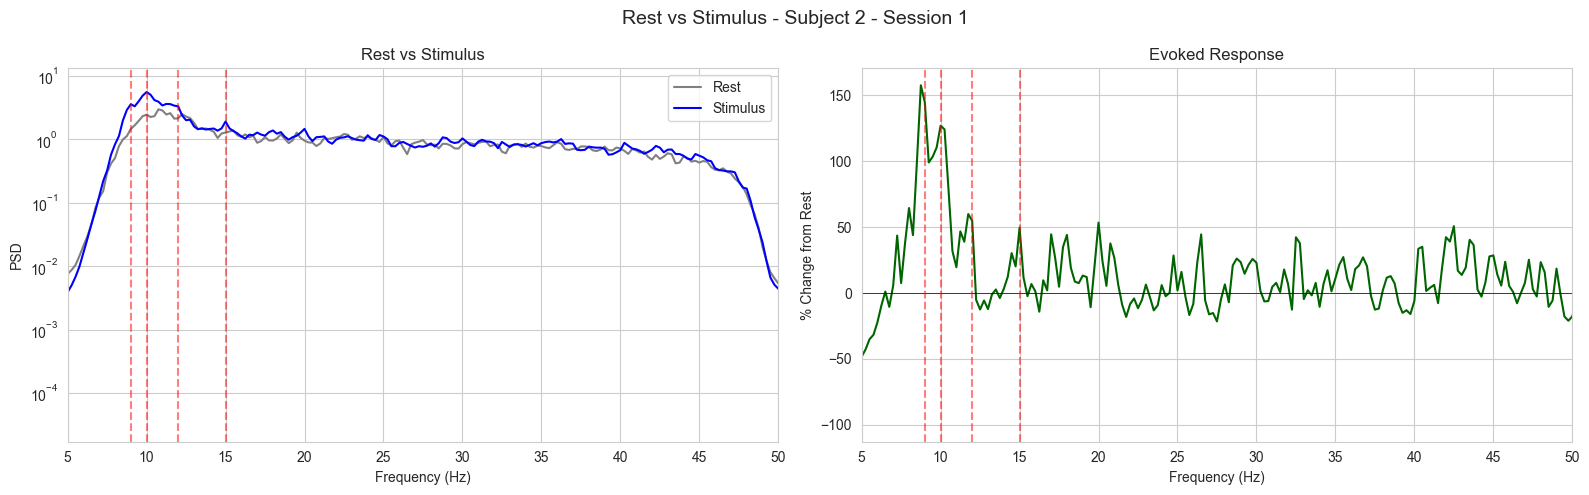

In [55]:
plot_rest_vs_stimulus(
    sub_2_sess_1,
    eeg_cols=EEG_COLS,
    stim_freqs=STIM_FREQS,
    title="Rest vs Stimulus - Subject 2 - Session 1",
    fs=FS,
)

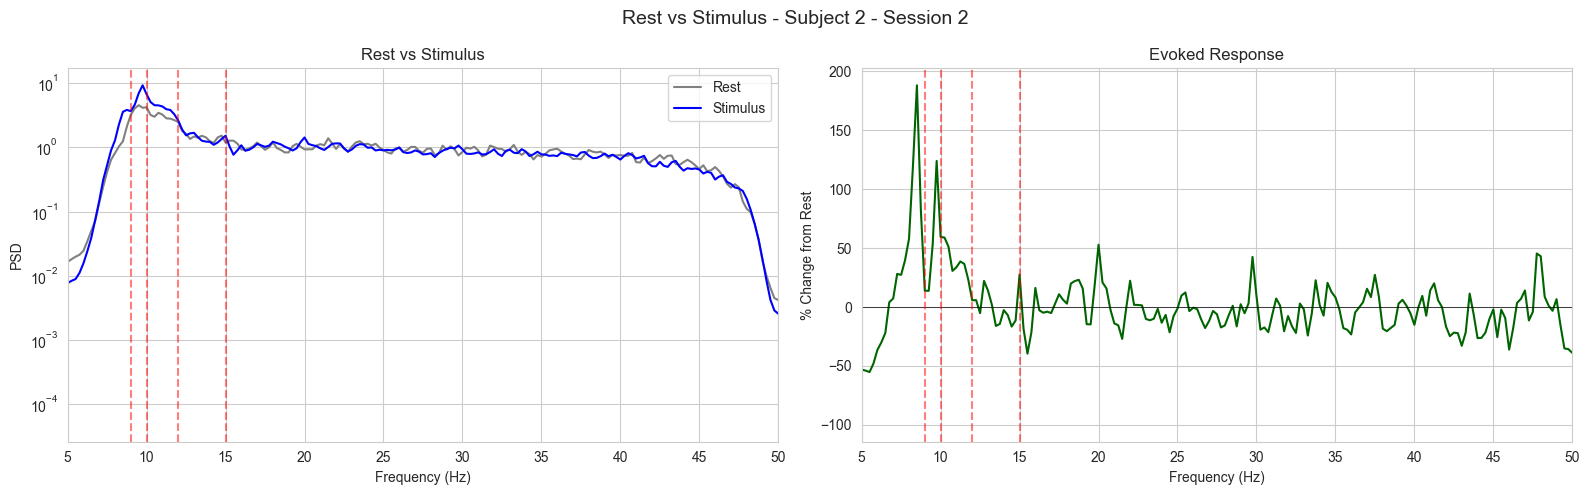

In [56]:
plot_rest_vs_stimulus(
    sub_2_sess_2,
    eeg_cols=EEG_COLS,
    stim_freqs=STIM_FREQS,
    title="Rest vs Stimulus - Subject 2 - Session 2",
    fs=FS,
)

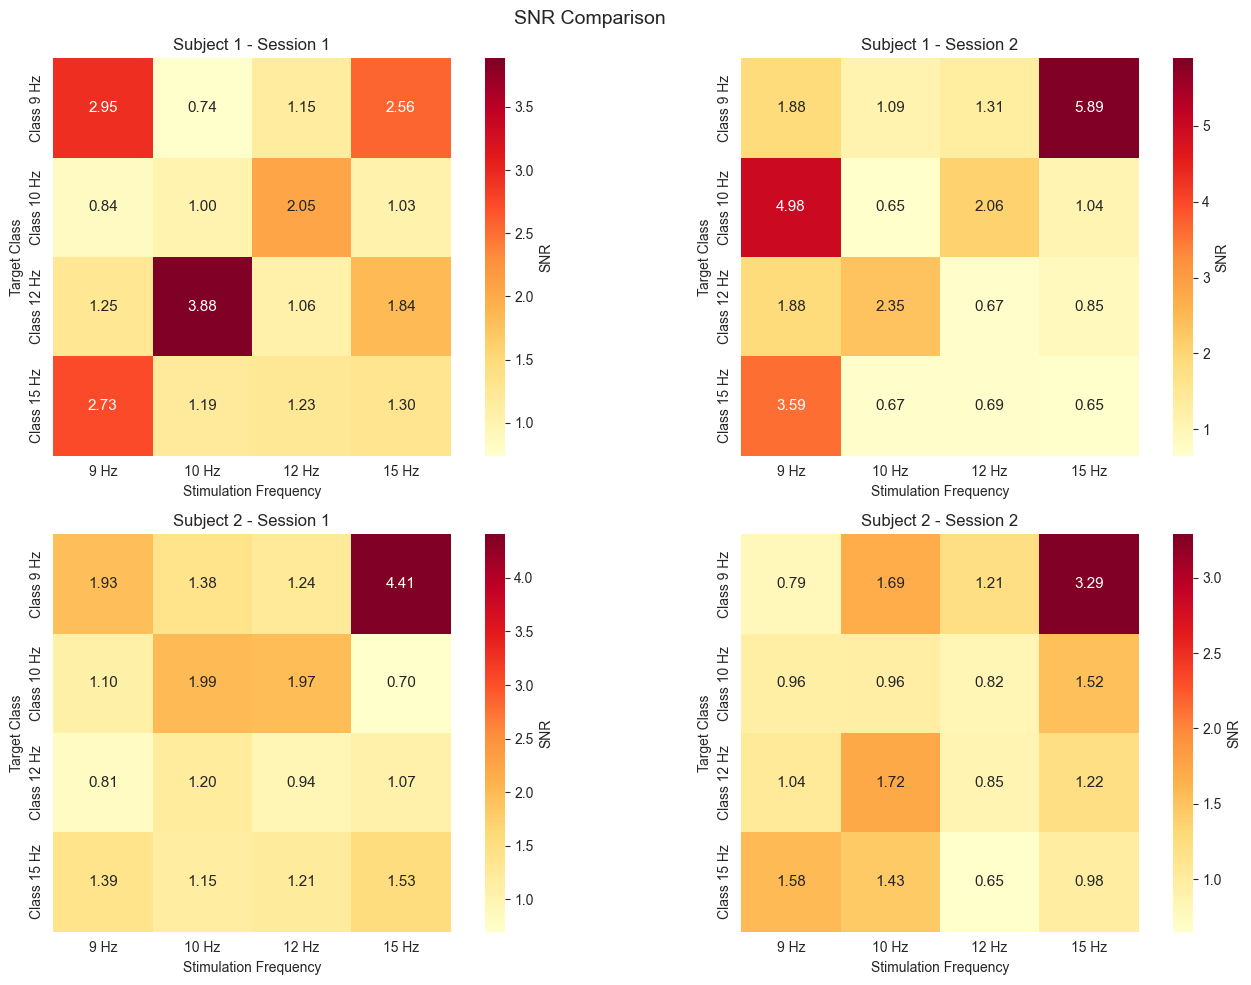

In [57]:
plot_snr_heatmap_compare(
    feat_dfs=[
        sub_1_sess_1_psd_feat,
        sub_1_sess_2_psd_feat,
        sub_2_sess_1_psd_feat,
        sub_2_sess_2_psd_feat,
    ],
    stim_freqs=STIM_FREQS,
    titles=[
        "Subject 1 - Session 1",
        "Subject 1 - Session 2",
        "Subject 2 - Session 1",
        "Subject 2 - Session 2",
    ],
    suptitle="SNR Comparison",
)

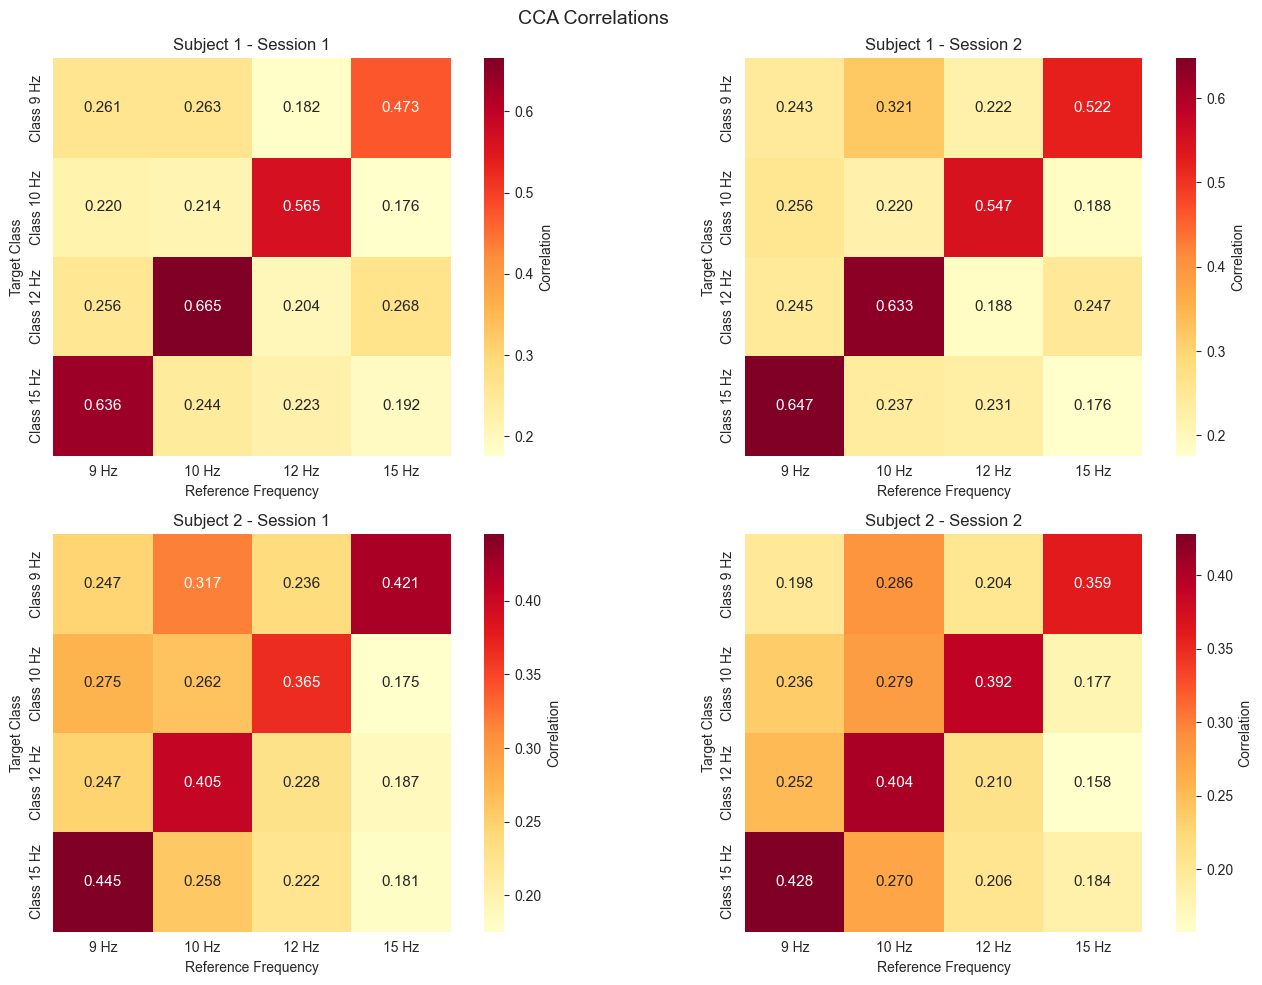

In [58]:
plot_cca_heatmap_compare(
    feat_dfs=[
        sub_1_sess_1_cca_feat,
        sub_1_sess_2_cca_feat,
        sub_2_sess_1_cca_feat,
        sub_2_sess_2_cca_feat,
    ],
    stim_freqs=STIM_FREQS,
    titles=[
        "Subject 1 - Session 1",
        "Subject 1 - Session 2",
        "Subject 2 - Session 1",
        "Subject 2 - Session 2",
    ],
    suptitle="CCA Correlations",
)

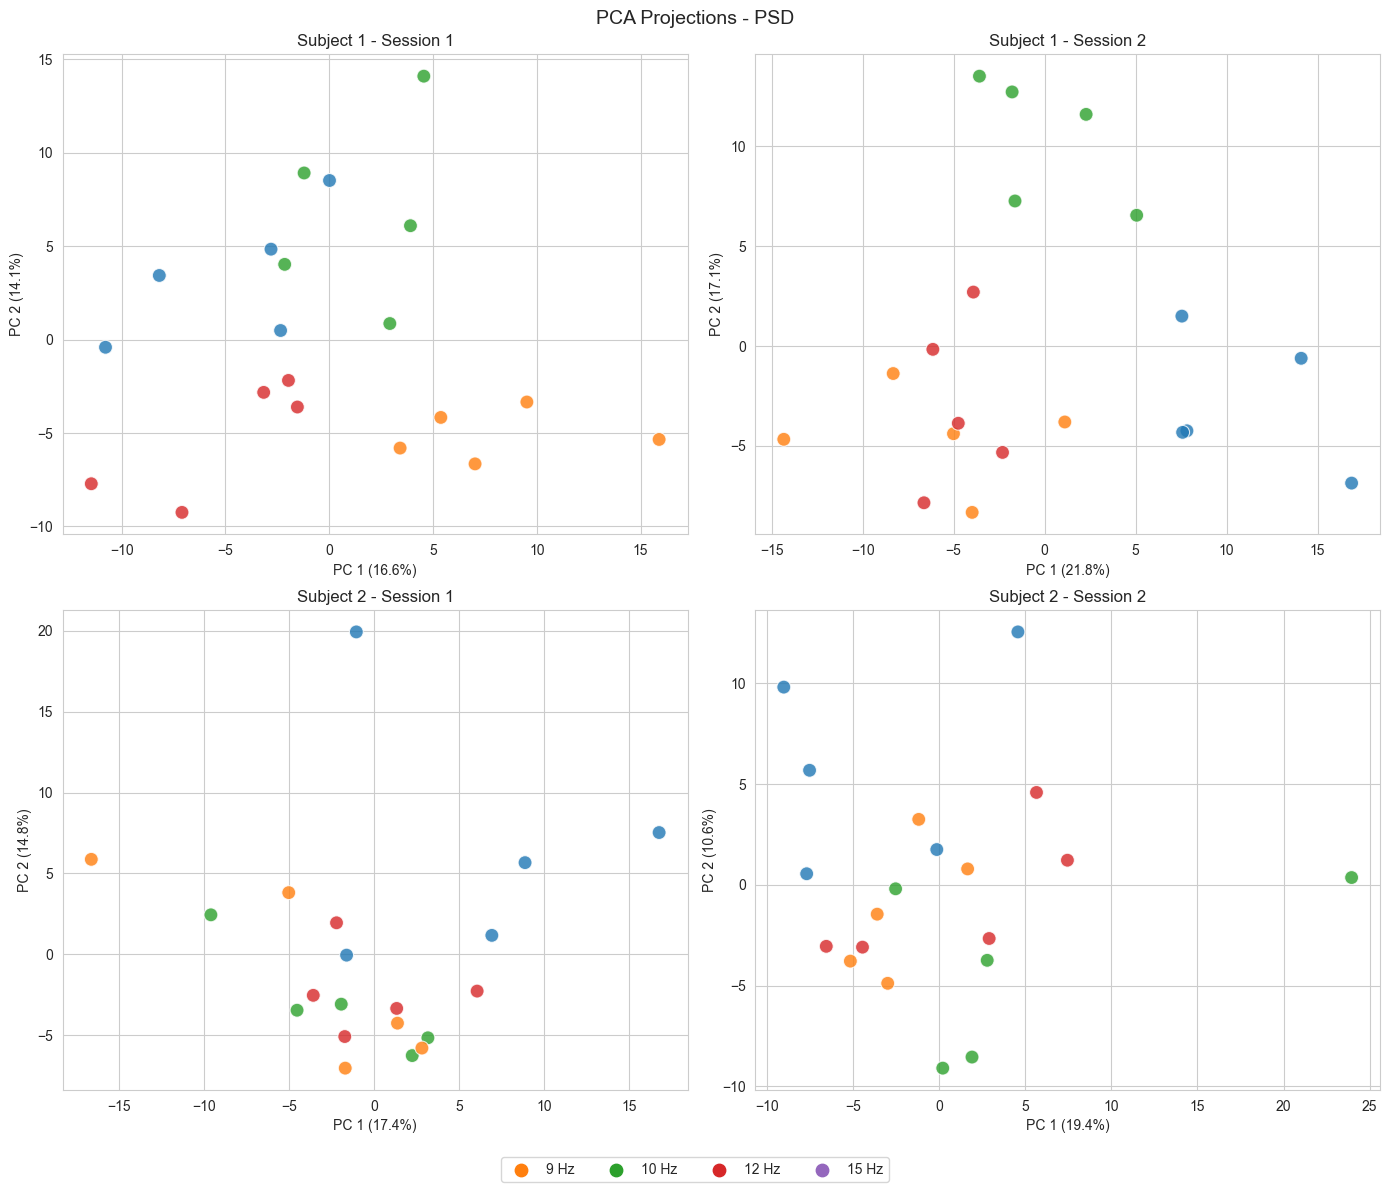

In [59]:
plot_feature_space(
    feat_dfs=[
        sub_1_sess_1_psd_feat,
        sub_1_sess_2_psd_feat,
        sub_2_sess_1_psd_feat,
        sub_2_sess_2_psd_feat,
    ],
    stim_freqs=STIM_FREQS,
    titles=[
        "Subject 1 - Session 1",
        "Subject 1 - Session 2",
        "Subject 2 - Session 1",
        "Subject 2 - Session 2",
    ],
    method="pca",
    suptitle="PCA Projections - PSD",
)

/Users/binivazquez/CodeWorkspace/hacks/brainwave-riders-ssvep/venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/binivazquez/CodeWorkspace/hacks/brainwave-riders-ssvep/venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/binivazquez/CodeWorkspace/hacks/brainwave-riders-ssvep/venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/binivazquez/CodeWorkspace/hacks/brainwave-riders-ssvep/venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


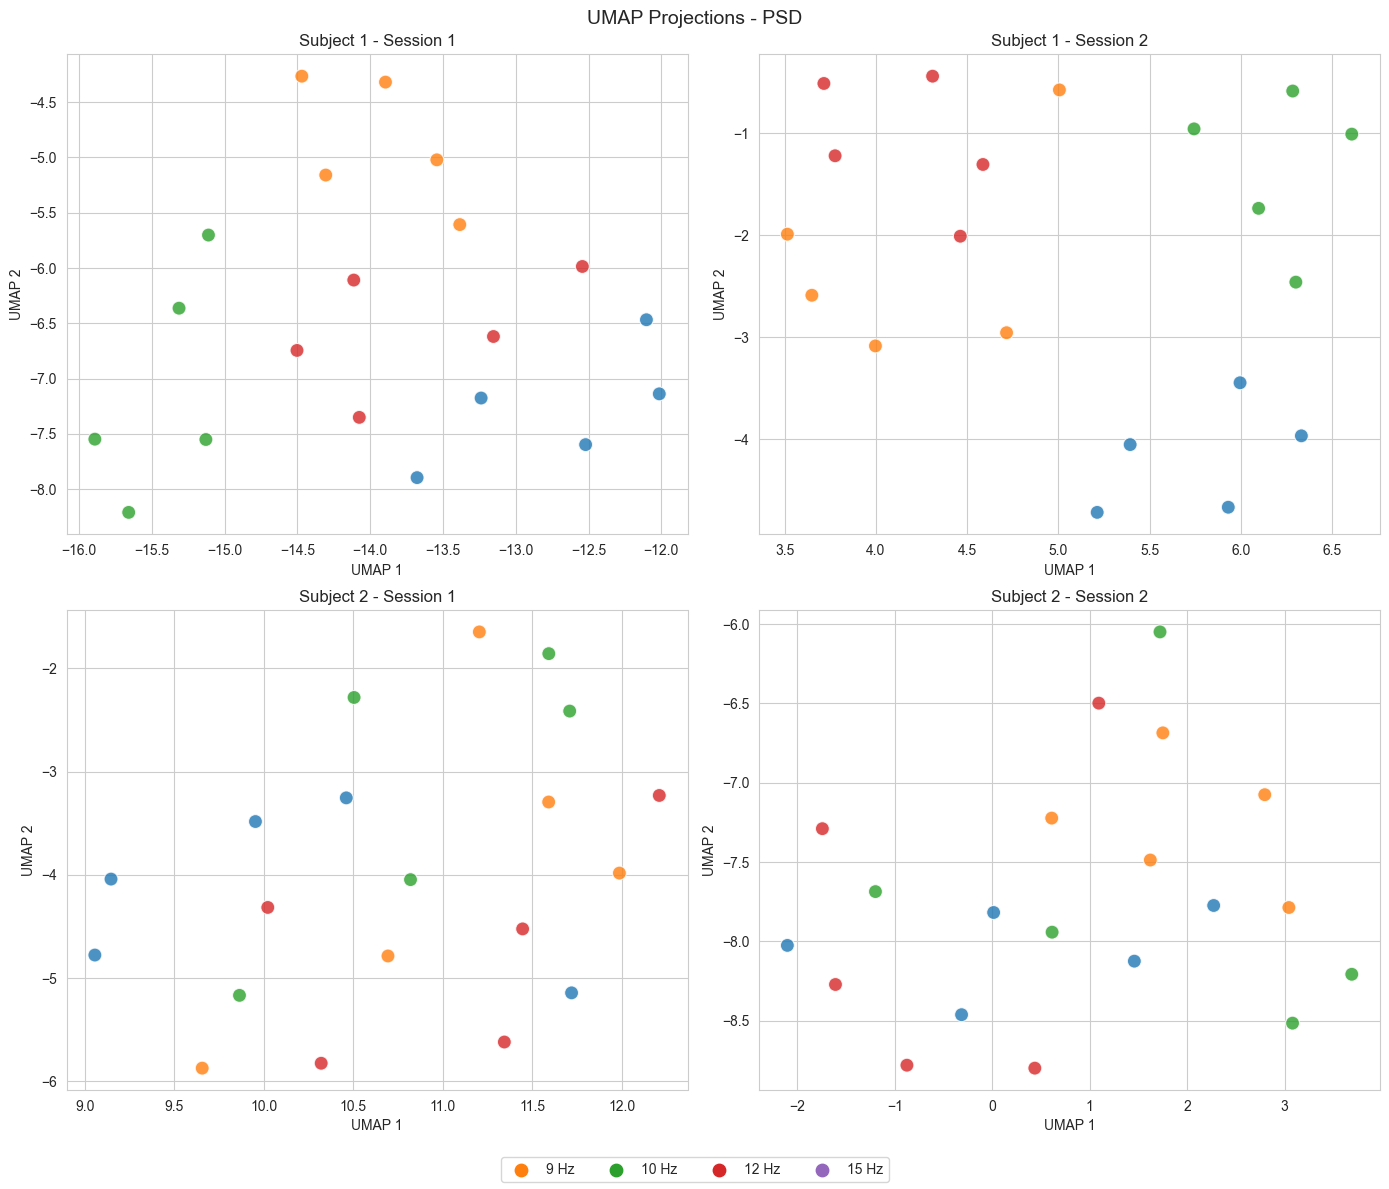

In [60]:
plot_feature_space(
    feat_dfs=[
        sub_1_sess_1_psd_feat,
        sub_1_sess_2_psd_feat,
        sub_2_sess_1_psd_feat,
        sub_2_sess_2_psd_feat,
    ],
    stim_freqs=STIM_FREQS,
    titles=[
        "Subject 1 - Session 1",
        "Subject 1 - Session 2",
        "Subject 2 - Session 1",
        "Subject 2 - Session 2",
    ],
    method="umap",
    suptitle="UMAP Projections - PSD",
)

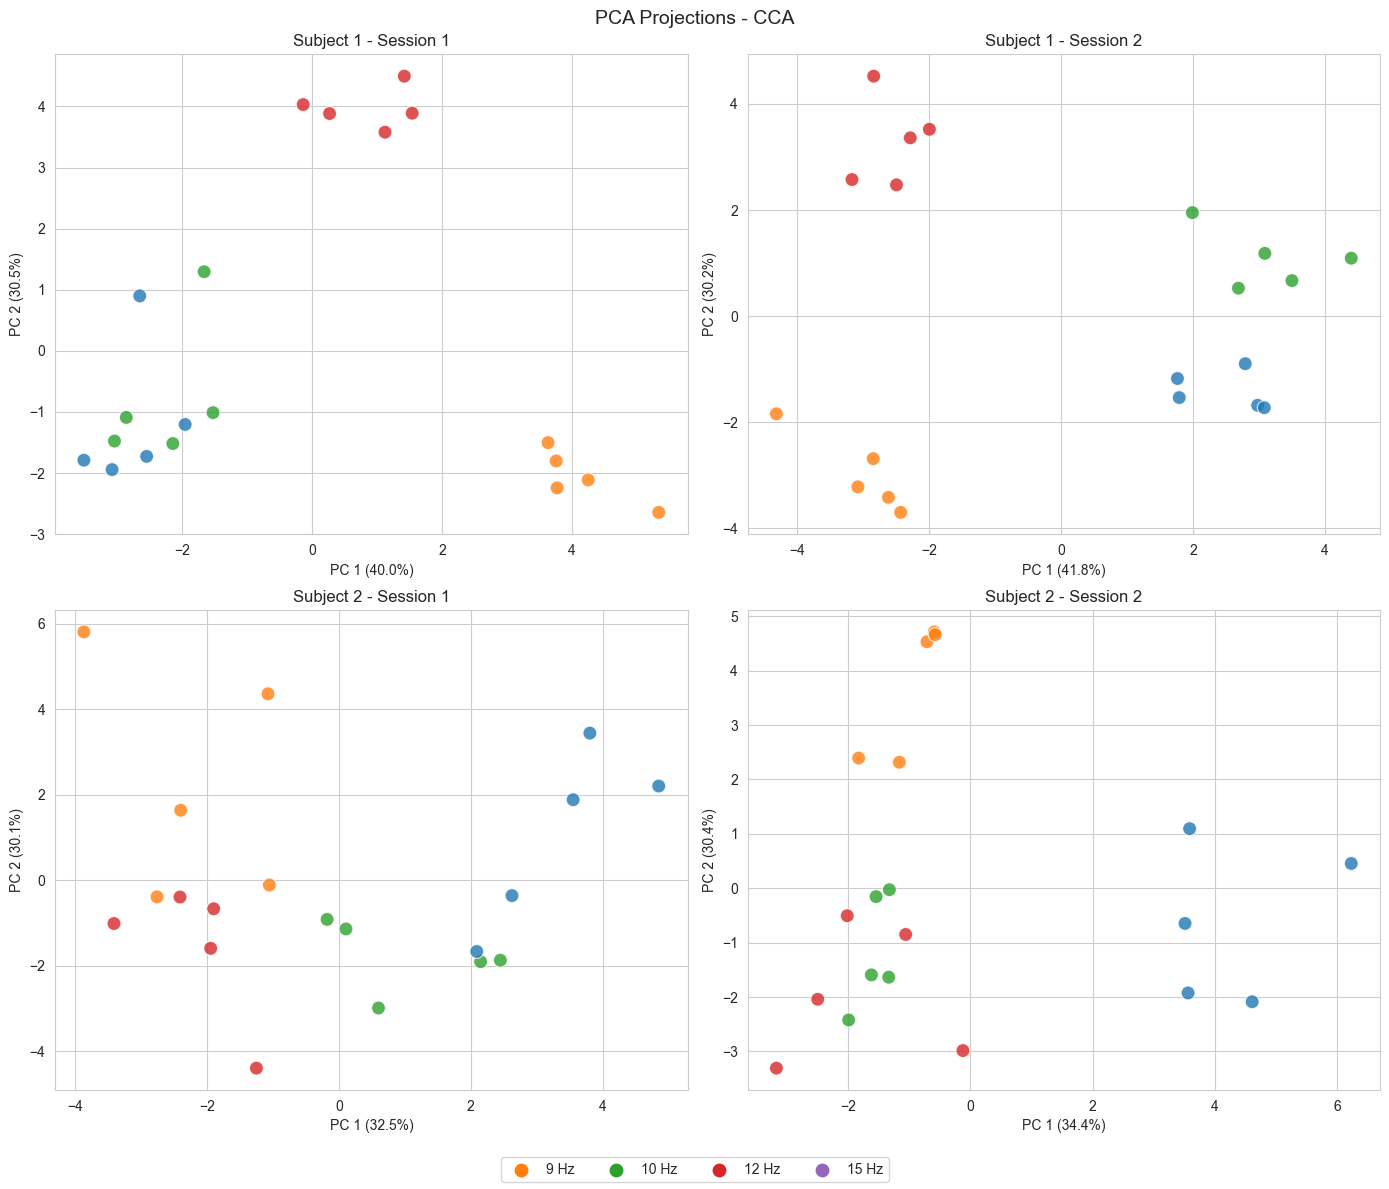

In [61]:
plot_feature_space(
    feat_dfs=[
        sub_1_sess_1_cca_feat,
        sub_1_sess_2_cca_feat,
        sub_2_sess_1_cca_feat,
        sub_2_sess_2_cca_feat,
    ],
    stim_freqs=STIM_FREQS,
    titles=[
        "Subject 1 - Session 1",
        "Subject 1 - Session 2",
        "Subject 2 - Session 1",
        "Subject 2 - Session 2",
    ],
    method="pca",
    suptitle="PCA Projections - CCA",
)

/Users/binivazquez/CodeWorkspace/hacks/brainwave-riders-ssvep/venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/binivazquez/CodeWorkspace/hacks/brainwave-riders-ssvep/venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/binivazquez/CodeWorkspace/hacks/brainwave-riders-ssvep/venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/binivazquez/CodeWorkspace/hacks/brainwave-riders-ssvep/venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


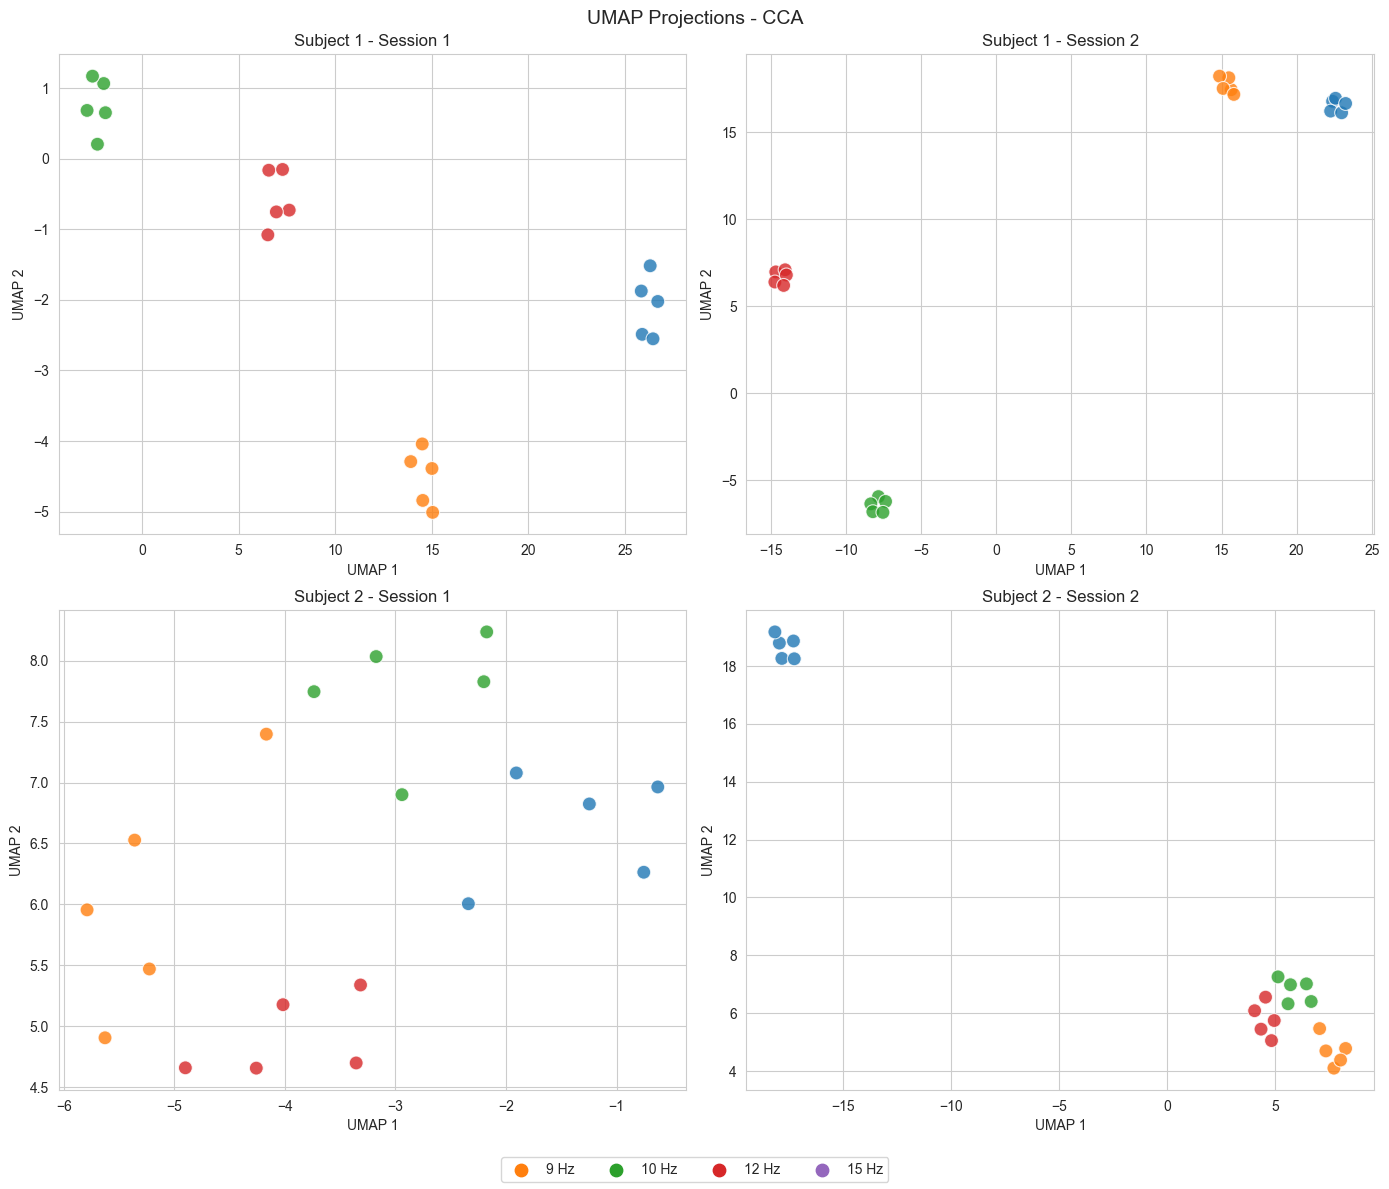

In [62]:
plot_feature_space(
    feat_dfs=[
        sub_1_sess_1_cca_feat,
        sub_1_sess_2_cca_feat,
        sub_2_sess_1_cca_feat,
        sub_2_sess_2_cca_feat,
    ],
    stim_freqs=STIM_FREQS,
    titles=[
        "Subject 1 - Session 1",
        "Subject 1 - Session 2",
        "Subject 2 - Session 1",
        "Subject 2 - Session 2",
    ],
    method="umap",
    suptitle="UMAP Projections - CCA",
)

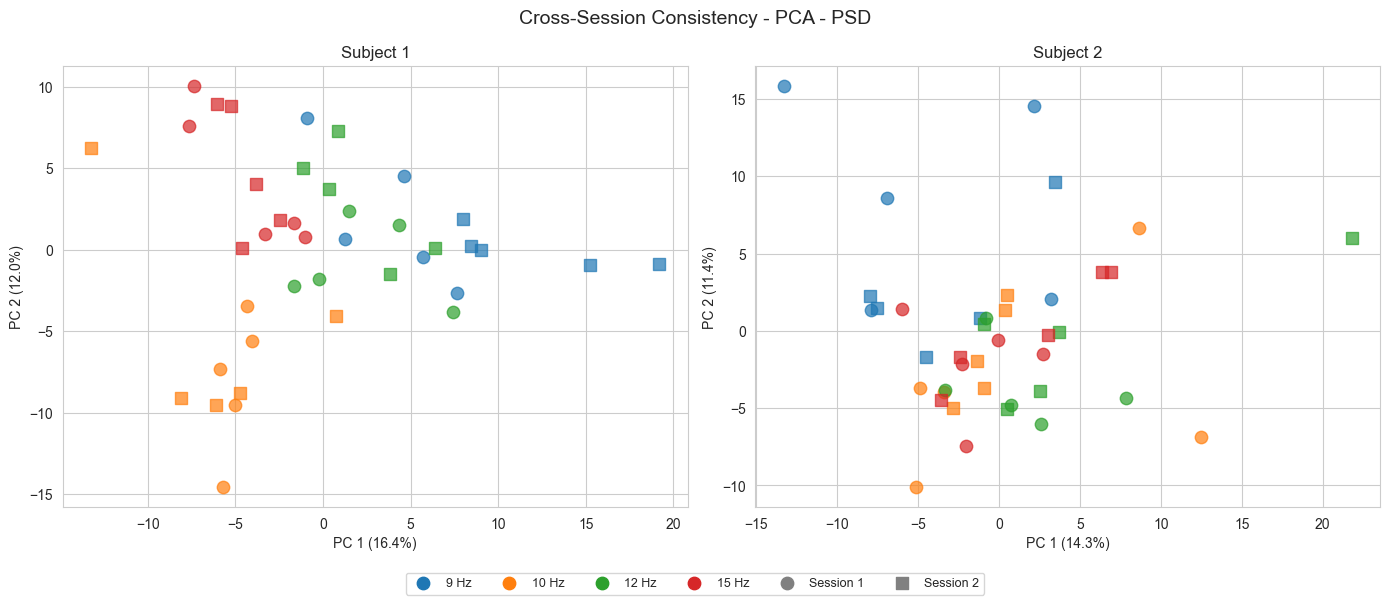

In [63]:
plot_feature_space_sessions(
    [
        [sub_1_sess_1_psd_feat, sub_1_sess_2_psd_feat],
        [sub_2_sess_1_psd_feat, sub_2_sess_2_psd_feat],
    ],
    stim_freqs=STIM_FREQS,
    titles=["Subject 1", "Subject 2"],
    method="pca",
    suptitle="Cross-Session Consistency - PCA - PSD",
)

/Users/binivazquez/CodeWorkspace/hacks/brainwave-riders-ssvep/venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/binivazquez/CodeWorkspace/hacks/brainwave-riders-ssvep/venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


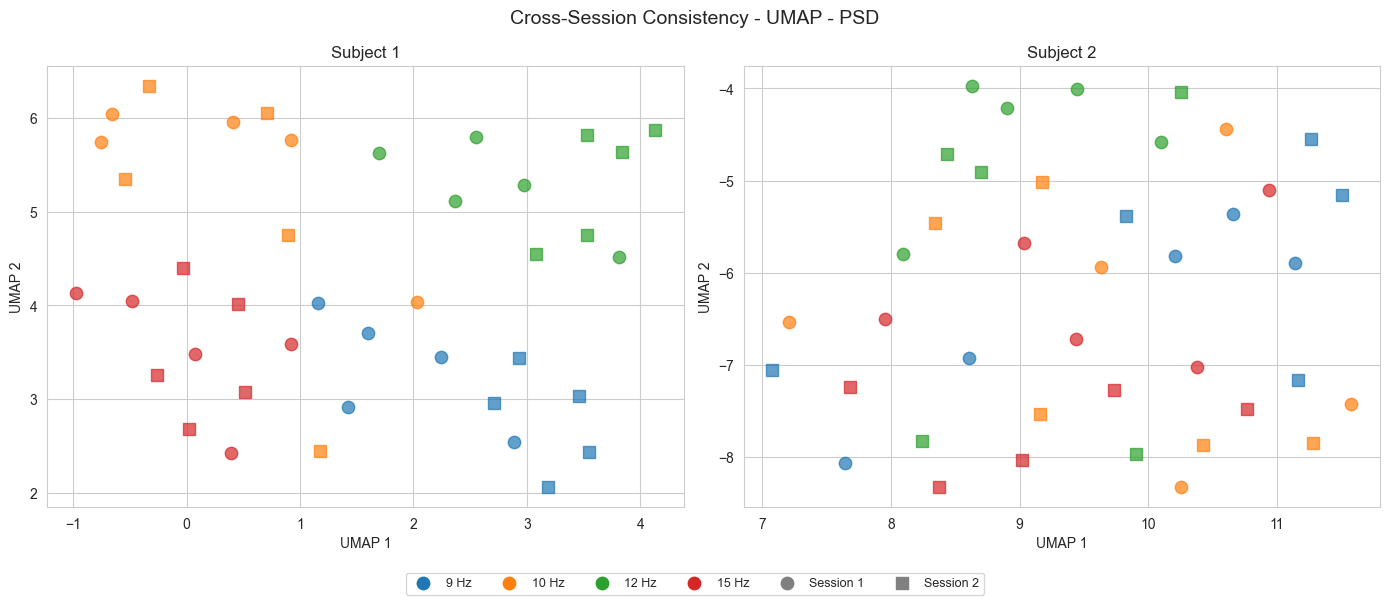

In [64]:
plot_feature_space_sessions(
    [
        [sub_1_sess_1_psd_feat, sub_1_sess_2_psd_feat],
        [sub_2_sess_1_psd_feat, sub_2_sess_2_psd_feat],
    ],
    stim_freqs=STIM_FREQS,
    titles=["Subject 1", "Subject 2"],
    method="umap",
    suptitle="Cross-Session Consistency - UMAP - PSD",
)

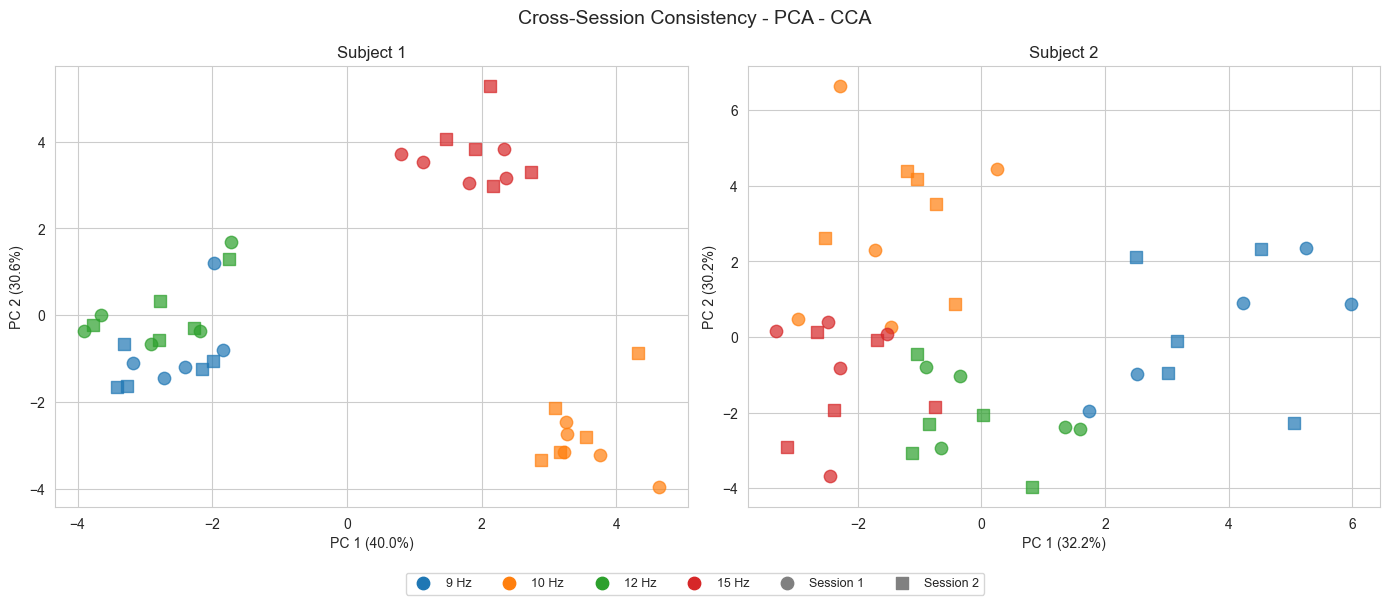

In [65]:
plot_feature_space_sessions(
    [
        [sub_1_sess_1_cca_feat, sub_1_sess_2_cca_feat],
        [sub_2_sess_1_cca_feat, sub_2_sess_2_cca_feat],
    ],
    stim_freqs=STIM_FREQS,
    titles=["Subject 1", "Subject 2"],
    method="pca",
    suptitle="Cross-Session Consistency - PCA - CCA",
)

/Users/binivazquez/CodeWorkspace/hacks/brainwave-riders-ssvep/venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/binivazquez/CodeWorkspace/hacks/brainwave-riders-ssvep/venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


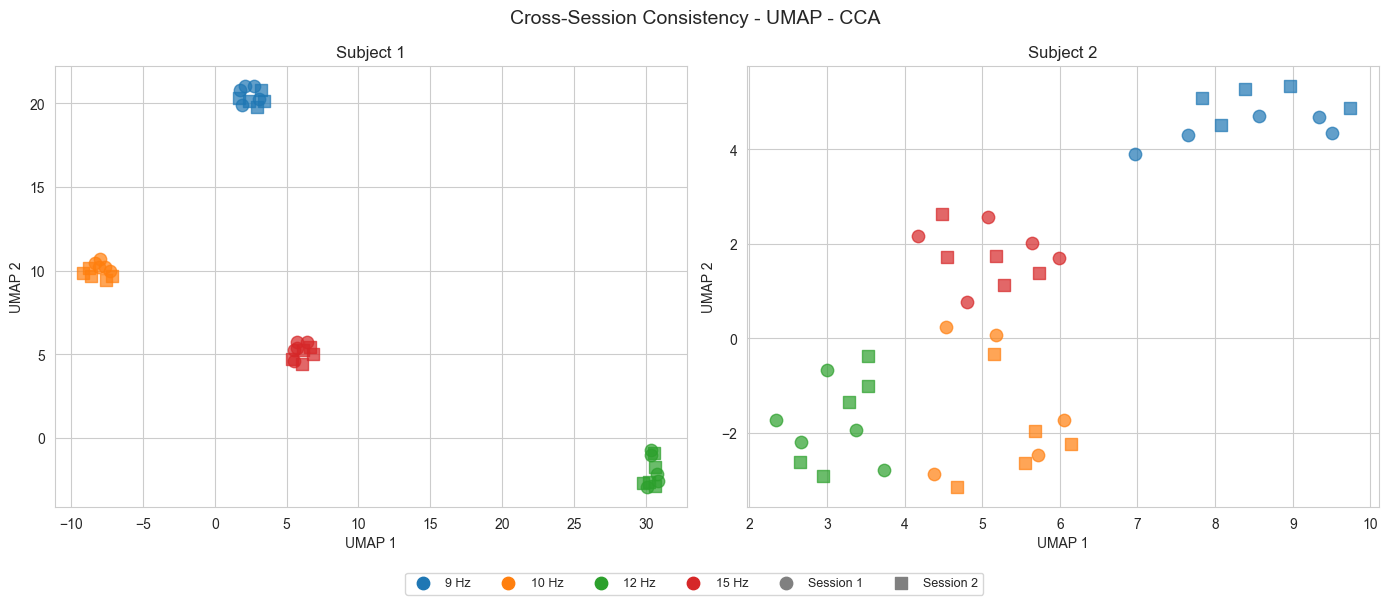

In [66]:
plot_feature_space_sessions(
    [
        [sub_1_sess_1_cca_feat, sub_1_sess_2_cca_feat],
        [sub_2_sess_1_cca_feat, sub_2_sess_2_cca_feat],
    ],
    stim_freqs=STIM_FREQS,
    titles=["Subject 1", "Subject 2"],
    method="umap",
    suptitle="Cross-Session Consistency - UMAP - CCA",
)

In [67]:
algs_and_params = {
    "SVM": {
        "params": {
            "model__kernel": ["linear", "rbf"],
            "model__C": [0.1, 1, 10, 100],
            "model__gamma": ["scale", "auto"],
        },
        "alg_class": SVC,
    },
    "LDA": {
        "params": {
            "model__solver": ["lsqr"],
            "model__shrinkage": [None, "auto", 0.1, 0.5, 0.9],
        },
        "alg_class": LinearDiscriminantAnalysis,
    },
}

In [68]:
# def run_nested_cv(feat_type, feat_sess_1, feat_sess_2, subject_name, algs_and_params):
#     """
#     Nested CV:
#         Outer loop: leave-one-session-out (2 splits)
#         Inner loop: LOOCV for hyperparameter tuning on training session
#     """

#     sessions = {
#         "Session 1": feat_sess_1,
#         "Session 2": feat_sess_2,
#     }

#     results = []

#     for alg, alg_info in algs_and_params.items():
#         # Outer loop: leave-one-session-out
#         for valid_sess_name, valid_df in sessions.items():
#             train_sess_name = [k for k in sessions if k != valid_sess_name][0]
#             train_df = sessions[train_sess_name]

#             X_train = train_df.drop(columns=["trial", "target"])
#             X_valid = valid_df.drop(columns=["trial", "target"])
#             y_train = train_df["target"]
#             y_valid = valid_df["target"]

#             # Inner loop: LOOCV on training session for hyperparameter tuning
#             grid = GridSearchCV(
#                 Pipeline(
#                     [("scaler", StandardScaler()), ("model", alg_info["alg_class"]())]
#                 ),
#                 alg_info["params"],
#                 cv=LeaveOneOut(),
#                 scoring="accuracy",
#                 refit=True,
#                 n_jobs=-1,
#                 return_train_score=True,
#             )
#             grid.fit(X_train, y_train)

#             results.append(
#                 {
#                     "subject": subject_name,
#                     "feat": feat_type,
#                     "alg": alg,
#                     "train_session": train_sess_name,
#                     "valid_session": valid_sess_name,
#                     "best_params": grid.best_params_,
#                     "train_cv_accuracy": grid.cv_results_["mean_train_score"][
#                         grid.best_index_
#                     ],
#                     "valid_cv_accuracy": grid.cv_results_["mean_test_score"][
#                         grid.best_index_
#                     ],
#                     "train_accuracy": accuracy_score(y_train, grid.predict(X_train)),
#                     "valid_accuracy": accuracy_score(y_valid, grid.predict(X_valid)),
#                     "y_valid": y_valid.to_numpy(),
#                     "y_pred": grid.predict(X_valid),
#                 }
#             )

#     return results
def run_nested_cv(
    feat_type,
    feat_sess_1,
    feat_sess_2,
    subject_name,
    algs_and_params,
    gap_lambda: float = 0.5,   # NEW: penalty weight on train-val gap
):
    """
    Nested CV:
        Outer loop: leave-one-session-out (2 splits)
        Inner loop: LOOCV for hyperparameter tuning on training session

    gap_lambda controls the composite selection criterion:
        composite = val_cv_accuracy - gap_lambda * (train_cv - val_cv)
    Set gap_lambda=0.0 to reproduce the original refit=True behaviour.
    Typical range: 0.3 – 1.0. Higher values prefer less-overfit models.
    """

    sessions = {
        "Session 1": feat_sess_1,
        "Session 2": feat_sess_2,
    }

    results = []

    for alg, alg_info in algs_and_params.items():
        for valid_sess_name, valid_df in sessions.items():
            train_sess_name = [k for k in sessions if k != valid_sess_name][0]
            train_df = sessions[train_sess_name]

            X_train = train_df.drop(columns=["trial", "target"])
            X_valid = valid_df.drop(columns=["trial", "target"])
            y_train = train_df["target"]
            y_valid = valid_df["target"]

            # refit=False — we'll select params manually below
            grid = GridSearchCV(
                Pipeline(
                    [("scaler", StandardScaler()), ("model", alg_info["alg_class"]())]
                ),
                alg_info["params"],
                cv=LeaveOneOut(),
                scoring="accuracy",
                refit=False,          # CHANGED: don't auto-refit on best_index_
                n_jobs=-1,
                return_train_score=True,
            )
            grid.fit(X_train, y_train)

            # --- NEW: composite selection ---
            cv_results = grid.cv_results_
            train_scores = cv_results["mean_train_score"]
            val_scores   = cv_results["mean_test_score"]
            gap          = train_scores - val_scores
            composite    = val_scores - gap_lambda * gap

            best_idx    = int(np.argmax(composite))
            best_params = cv_results["params"][best_idx]

            # Refit a fresh estimator on the full training session
            # using the composite-selected params
            best_pipe = Pipeline(
                [("scaler", StandardScaler()), ("model", alg_info["alg_class"](**{
                    # strip the "model__" prefix that GridSearchCV adds
                    k.replace("model__", ""): v
                    for k, v in best_params.items()
                }))]
            )
            best_pipe.fit(X_train, y_train)
            # --------------------------------

            results.append(
                {
                    "subject":           subject_name,
                    "feat":              feat_type,
                    "alg":               alg,
                    "train_session":     train_sess_name,
                    "valid_session":     valid_sess_name,
                    "gap_lambda":        gap_lambda,          # NEW: track it
                    "best_params":       best_params,
                    "composite_score":   float(composite[best_idx]),  # NEW
                    "train_cv_accuracy": float(train_scores[best_idx]),
                    "valid_cv_accuracy": float(val_scores[best_idx]),
                    "cv_gap":            float(gap[best_idx]),         # NEW
                    "train_accuracy":    accuracy_score(y_train, best_pipe.predict(X_train)),
                    "valid_accuracy":    accuracy_score(y_valid, best_pipe.predict(X_valid)),
                    "y_valid":           y_valid.to_numpy(),
                    "y_pred":            best_pipe.predict(X_valid),
                }
            )
            

    return results

In [69]:
all_results = []

for (
    feat,
    subject,
    sess_1,
    sess_2,
) in [
    ("PSD", "Subject 1", sub_1_sess_1_psd_feat, sub_1_sess_2_psd_feat),
    ("PSD", "Subject 2", sub_2_sess_1_psd_feat, sub_2_sess_2_psd_feat),
    ("CCA", "Subject 1", sub_1_sess_1_cca_feat, sub_1_sess_2_cca_feat),
    ("CCA", "Subject 2", sub_2_sess_1_cca_feat, sub_2_sess_2_cca_feat),
]:
    results = run_nested_cv(feat, sess_1, sess_2, subject, algs_and_params)
    all_results.append(results)

/Users/binivazquez/CodeWorkspace/hacks/brainwave-riders-ssvep/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/binivazquez/CodeWorkspace/hacks/brainwave-riders-ssvep/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/binivazquez/CodeWorkspace/hacks/brainwave-riders-ssvep/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/binivazquez/CodeWorkspace/hacks/brainwave-riders-ssvep/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/binivazquez/CodeWorkspace/hacks/brainwave-riders-ssvep/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/binivazquez/CodeWorkspace/hacks/brainwave-ride

In [70]:
results_df = pd.concat([pd.DataFrame(res) for res in all_results], ignore_index=True)

In [71]:
results_df.drop(columns=["y_valid", "y_pred"]).style.highlight_max(
    subset=["train_accuracy", "valid_accuracy"], color="lightgreen"
)

,subject,feat,alg,train_session,valid_session,gap_lambda,best_params,composite_score,train_cv_accuracy,valid_cv_accuracy,cv_gap,train_accuracy,valid_accuracy
0,Subject 1,PSD,SVM,Session 2,Session 1,0.500000,"{'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'linear'}",0.925000,1.000000,0.950000,0.050000,1.000000,0.850000
1,Subject 1,PSD,SVM,Session 1,Session 2,0.500000,"{'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'linear'}",0.625000,1.000000,0.750000,0.250000,1.000000,1.000000
2,Subject 1,PSD,LDA,Session 2,Session 1,0.500000,"{'model__shrinkage': 0.1, 'model__solver': 'lsqr'}",0.925000,1.000000,0.950000,0.050000,1.000000,0.850000
3,Subject 1,PSD,LDA,Session 1,Session 2,0.500000,"{'model__shrinkage': 'auto', 'model__solver': 'lsqr'}",0.775000,1.000000,0.850000,0.150000,1.000000,0.900000
4,Subject 2,PSD,SVM,Session 2,Session 1,0.500000,"{'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'linear'}",0.175000,1.000000,0.450000,0.550000,1.000000,0.600000
5,Subject 2,PSD,SVM,Session 1,Session 2,0.500000,"{'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'linear'}",0.325000,1.000000,0.550000,0.450000,1.000000,0.450000
6,Subject 2,PSD,LDA,Session 2,Session 1,0.500000,"{'model__shrinkage': None, 'model__solver': 'lsqr'}",0.388158,0.273684,0.350000,-0.076316,0.000000,0.400000
7,Subject 2,PSD,LDA,Session 1,Session 2,0.500000,"{'model__shrinkage': 0.9, 'model__solver': 'lsqr'}",0.400000,1.000000,0.600000,0.400000,1.000000,0.550000
8,Subject 1,CCA,SVM,Session 2,Session 1,0.500000,"{'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'linear'}",1.000000,1.000000,1.000000,0.000000,1.000000,1.000000
9,Subject 1,CCA,SVM,Session 1,Session 2,0.500000,"{'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'linear'}",1.000000,1.000000,1.000000,0.000000,1.000000,1.000000


TODO:

1. Sliding window
2. Different window size
3. Different skip size
4. Choose a less overfitted model during HPO (and don't trust refit as it only looks at validation splits)
5. Visualize confusion matrices (because we have 100% almost everywhere, it is not present them)

In [72]:
from scipy.stats import spearmanr


def fit_cross_session_trial_predictions(
    feat_sess_1, feat_sess_2, algs_and_params, gap_lambda=0.5
):
    sessions = {
        "Session 1": feat_sess_1.copy(),
        "Session 2": feat_sess_2.copy(),
    }

    rows = []

    for alg, alg_info in algs_and_params.items():
        for valid_sess_name, valid_df in sessions.items():
            train_sess_name = [k for k in sessions if k != valid_sess_name][0]
            train_df = sessions[train_sess_name]

            X_train = train_df.drop(columns=["trial", "target"])
            X_valid = valid_df.drop(columns=["trial", "target"])
            y_train = train_df["target"]
            y_valid = valid_df["target"]

            grid = GridSearchCV(
                Pipeline(
                    [("scaler", StandardScaler()), ("model", alg_info["alg_class"]())]
                ),
                alg_info["params"],
                cv=LeaveOneOut(),
                scoring="accuracy",
                refit=False,
                n_jobs=-1,
                return_train_score=True,
            )
            grid.fit(X_train, y_train)

            cv_results = grid.cv_results_
            train_scores = cv_results["mean_train_score"]
            val_scores = cv_results["mean_test_score"]
            gap = train_scores - val_scores
            composite = val_scores - gap_lambda * gap

            best_idx = int(np.argmax(composite))
            best_params = cv_results["params"][best_idx]
            model_kwargs = {
                k.replace("model__", ""): v for k, v in best_params.items()
            }
            best_pipe = Pipeline(
                [("scaler", StandardScaler()), ("model", alg_info["alg_class"](**model_kwargs))]
            )
            best_pipe.fit(X_train, y_train)

            y_pred = best_pipe.predict(X_valid)
            for trial, target, pred in zip(valid_df["trial"], y_valid, y_pred):
                rows.append(
                    {
                        "alg": alg,
                        "train_session": train_sess_name,
                        "valid_session": valid_sess_name,
                        "trial": int(trial),
                        "target": float(target),
                        "pred": float(pred),
                        "correct": int(pred == target),
                        "valid_accuracy": float(accuracy_score(y_valid, y_pred)),
                        "composite_score": float(composite[best_idx]),
                    }
                )

    return pd.DataFrame(rows)


def summarize_subject_trials(psd_feat, cca_feat, session_name, cca_h=3):
    rows = []

    for _, psd_row in psd_feat.iterrows():
        target = int(psd_row["target"])
        trial = int(psd_row["trial"])

        snr_cols = [f"ch{ch+1}_snr_{target}Hz_h1" for ch in range(len(EEG_COLS))]
        psd_cols = [f"ch{ch+1}_psd_{target}Hz_h1" for ch in range(len(EEG_COLS))]
        rel_cols = [f"ch{ch+1}_relpower_{target}Hz" for ch in range(len(EEG_COLS))]

        row = {
            "session": session_name,
            "trial": trial,
            "target": target,
            "snr_target_h1_mean": float(psd_row[snr_cols].mean()),
            "snr_target_h1_max": float(psd_row[snr_cols].max()),
            "psd_target_h1_mean": float(psd_row[psd_cols].mean()),
            "relpower_target_mean": float(psd_row[rel_cols].mean()),
        }

        cca_row = cca_feat.loc[cca_feat["trial"] == trial].iloc[0]
        row[f"cca_target_h{cca_h}"] = float(cca_row[f"cca_{target}Hz_h{cca_h}"])
        row["cca_target_best"] = float(
            cca_row[[c for c in cca_feat.columns if c.startswith("cca_")]].max()
        )

        rows.append(row)

    return pd.DataFrame(rows)


def select_best_transfer_predictions(pred_df, feat_name):
    best = (
        pred_df.sort_values(
            ["valid_session", "valid_accuracy", "composite_score"],
            ascending=[True, False, False],
        )
        .groupby("valid_session", as_index=False)
        .first()[["valid_session", "alg", "valid_accuracy"]]
        .rename(
            columns={
                "alg": f"best_alg_{feat_name.lower()}",
                "valid_accuracy": f"best_valid_accuracy_{feat_name.lower()}",
            }
        )
    )

    selected = pred_df.merge(best, on="valid_session")
    selected = selected[selected["alg"] == selected[f"best_alg_{feat_name.lower()}"]].copy()
    return selected


def build_subject_2_trial_diagnostics(
    sess_1_psd, sess_2_psd, sess_1_cca, sess_2_cca, algs_and_params, gap_lambda=0.5, cca_h=3
):
    trial_summary = pd.concat(
        [
            summarize_subject_trials(sess_1_psd, sess_1_cca, "Session 1", cca_h=cca_h),
            summarize_subject_trials(sess_2_psd, sess_2_cca, "Session 2", cca_h=cca_h),
        ],
        ignore_index=True,
    )

    psd_pred = fit_cross_session_trial_predictions(
        sess_1_psd, sess_2_psd, algs_and_params, gap_lambda=gap_lambda
    )
    cca_pred = fit_cross_session_trial_predictions(
        sess_1_cca, sess_2_cca, algs_and_params, gap_lambda=gap_lambda
    )

    psd_best = select_best_transfer_predictions(psd_pred, "psd")
    cca_best = select_best_transfer_predictions(cca_pred, "cca")

    diag = trial_summary.merge(
        psd_best[[
            "valid_session",
            "trial",
            "pred",
            "correct",
            "best_alg_psd",
            "best_valid_accuracy_psd",
        ]].rename(
            columns={
                "valid_session": "session",
                "pred": "pred_psd",
                "correct": "transfer_correct_psd",
            }
        ),
        on=["session", "trial"],
        how="left",
    ).merge(
        cca_best[[
            "valid_session",
            "trial",
            "pred",
            "correct",
            "best_alg_cca",
            "best_valid_accuracy_cca",
        ]].rename(
            columns={
                "valid_session": "session",
                "pred": "pred_cca",
                "correct": "transfer_correct_cca",
            }
        ),
        on=["session", "trial"],
        how="left",
    )

    diag["transfer_correct_any"] = diag[["transfer_correct_psd", "transfer_correct_cca"]].max(axis=1)
    return diag, psd_pred, cca_pred


def report_subject_2_correlations(diag_df, cca_h=3):
    corr_rows = []
    metrics = {
        "transfer_correct_psd": "Cross-session correctness (PSD)",
        "transfer_correct_cca": "Cross-session correctness (CCA)",
        "psd_target_h1_mean": "Target PSD strength",
        f"cca_target_h{cca_h}": f"CCA target score (h={cca_h})",
    }

    for metric, label in metrics.items():
        rho, pvalue = spearmanr(diag_df["snr_target_h1_mean"], diag_df[metric])
        corr_rows.append(
            {
                "metric": label,
                "spearman_rho": float(rho),
                "p_value": float(pvalue),
            }
        )

    return pd.DataFrame(corr_rows)


def plot_subject_2_snr_correlations(diag_df, cca_h=3):
    plot_df = diag_df.copy()
    plot_df = plot_df.sort_values(["session", "trial"]).reset_index(drop=True)
    plot_df["transfer_correct_psd_jitter"] = plot_df["transfer_correct_psd"] + np.linspace(-0.04, 0.04, len(plot_df))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    sns.scatterplot(
        data=plot_df,
        x="snr_target_h1_mean",
        y="transfer_correct_psd_jitter",
        hue="session",
        style="target",
        s=80,
        ax=axes[0],
    )
    axes[0].set_ylabel("Cross-session correct (PSD, jittered)")
    axes[0].set_xlabel("Mean target SNR (h1)")
    axes[0].set_title("SNR vs cross-session success")

    sns.regplot(
        data=plot_df,
        x="snr_target_h1_mean",
        y="psd_target_h1_mean",
        scatter=False,
        color="black",
        ax=axes[1],
    )
    sns.scatterplot(
        data=plot_df,
        x="snr_target_h1_mean",
        y="psd_target_h1_mean",
        hue="session",
        style="target",
        s=80,
        legend=False,
        ax=axes[1],
    )
    axes[1].set_xlabel("Mean target SNR (h1)")
    axes[1].set_ylabel("Mean target PSD (h1)")
    axes[1].set_title("SNR vs PSD feature strength")

    sns.regplot(
        data=plot_df,
        x="snr_target_h1_mean",
        y=f"cca_target_h{cca_h}",
        scatter=False,
        color="black",
        ax=axes[2],
    )
    sns.scatterplot(
        data=plot_df,
        x="snr_target_h1_mean",
        y=f"cca_target_h{cca_h}",
        hue="session",
        style="target",
        s=80,
        legend=False,
        ax=axes[2],
    )
    axes[2].set_xlabel("Mean target SNR (h1)")
    axes[2].set_ylabel(f"CCA target correlation (h={cca_h})")
    axes[2].set_title("SNR vs CCA target score")

    handles, labels = axes[0].get_legend_handles_labels()
    axes[0].legend(handles, labels, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.suptitle("Subject 2 trial-level SNR diagnostics", fontsize=14)
    plt.tight_layout()
    plt.show()


/Users/binivazquez/CodeWorkspace/hacks/brainwave-riders-ssvep/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/binivazquez/CodeWorkspace/hacks/brainwave-riders-ssvep/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/binivazquez/CodeWorkspace/hacks/brainwave-riders-ssvep/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/binivazquez/CodeWorkspace/hacks/brainwave-riders-ssvep/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/binivazquez/CodeWorkspace/hacks/brainwave-riders-ssvep/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/binivazquez/CodeWorkspace/hacks/brainwave-ride

,metric,spearman_rho,p_value
2,Target PSD strength,0.530957,0.000424
3,CCA target score (h=3),0.000188,0.999083
0,Cross-session correctness (PSD),-0.046001,0.778051
1,Cross-session correctness (CCA),NaN,NaN


,session,trial,target,snr_target_h1_mean,psd_target_h1_mean,cca_target_h3,transfer_correct_psd,transfer_correct_cca,best_alg_psd,best_alg_cca
0,Session 1,1,9,1.248561,1.053818,0.219994,1,1,SVM,SVM
1,Session 1,2,10,0.772451,1.041961,0.208995,1,1,SVM,SVM
2,Session 1,3,12,0.389305,1.294144,0.194040,0,1,SVM,SVM
3,Session 1,4,15,4.319308,3.090968,0.154566,0,1,SVM,SVM
4,Session 1,5,9,2.696720,0.985751,0.207300,1,1,SVM,SVM
5,Session 1,6,10,6.230339,35.160625,0.393237,1,1,SVM,SVM
6,Session 1,7,12,0.781346,1.261693,0.194379,1,1,SVM,SVM
7,Session 1,8,15,0.874907,1.463543,0.155391,1,1,SVM,SVM
8,Session 1,9,9,4.105918,26.740388,0.404202,1,1,SVM,SVM
9,Session 1,10,10,0.815103,2.729773,0.192174,1,1,SVM,SVM


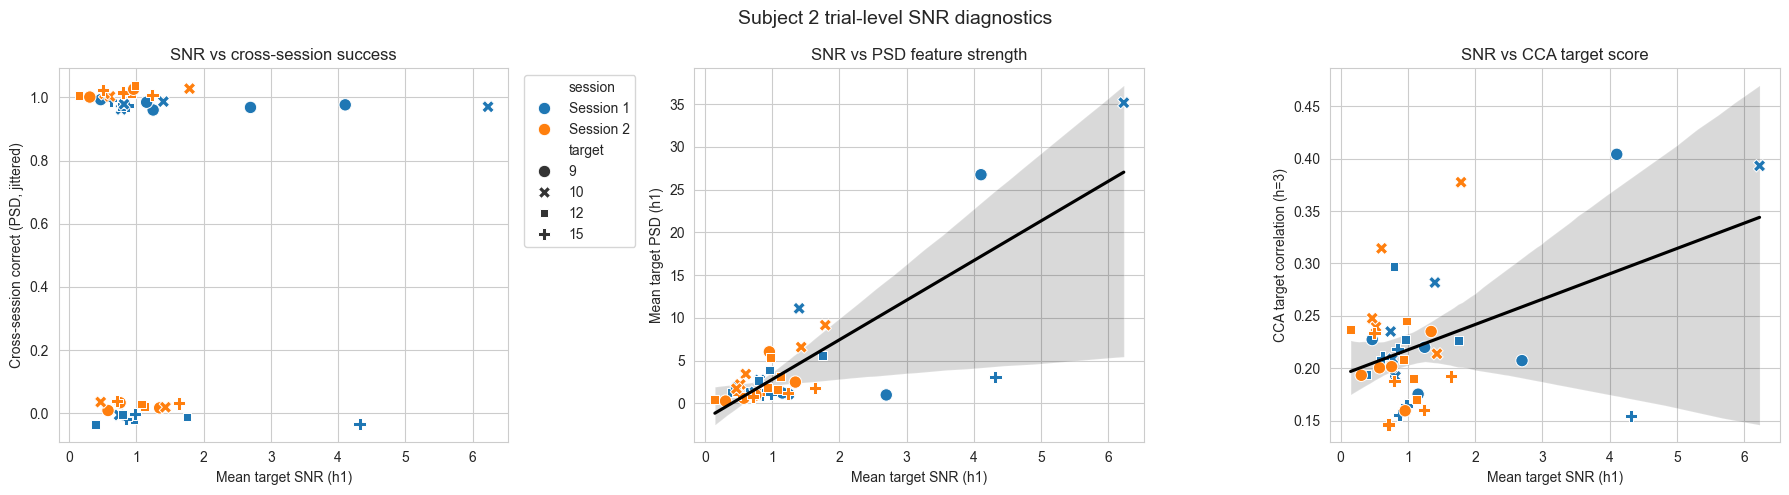

,snr_target_h1_mean,psd_target_h1_mean,cca_target_h3,transfer_correct_psd,transfer_correct_cca
session,,,,,
Session 1,1.598,5.290,0.229,0.60,1.0
Session 2,0.895,2.595,0.218,0.55,1.0


In [73]:
subject_2_trial_diag, subject_2_psd_trial_pred, subject_2_cca_trial_pred = build_subject_2_trial_diagnostics(
    sub_2_sess_1_psd_feat,
    sub_2_sess_2_psd_feat,
    sub_2_sess_1_cca_feat,
    sub_2_sess_2_cca_feat,
    algs_and_params,
    gap_lambda=0.5,
    cca_h=3,
)

snr_per_trial = subject_2_trial_diag["snr_target_h1_mean"].to_numpy()
valid_acc_per_trial = subject_2_trial_diag.groupby("session")["transfer_correct_psd"].apply(list).to_dict()

subject_2_corr_summary = report_subject_2_correlations(subject_2_trial_diag, cca_h=3)
display(subject_2_corr_summary.sort_values("spearman_rho", ascending=False))
display(
    subject_2_trial_diag[[
        "session",
        "trial",
        "target",
        "snr_target_h1_mean",
        "psd_target_h1_mean",
        "cca_target_h3",
        "transfer_correct_psd",
        "transfer_correct_cca",
        "best_alg_psd",
        "best_alg_cca",
    ]].sort_values(["session", "trial"]).head(10)
)

plot_subject_2_snr_correlations(subject_2_trial_diag, cca_h=3)

subject_2_trial_diag.groupby("session")[[
    "snr_target_h1_mean",
    "psd_target_h1_mean",
    "cca_target_h3",
    "transfer_correct_psd",
    "transfer_correct_cca",
]].mean().round(3)


In [74]:
# ── Nested CV: FBCCA ──────────────────────────────────────────────────────
fbcca_results = []
for feat, subject, sess_1, sess_2 in [
    ("FBCCA", "Subject 1", sub_1_sess_1_fbcca_feat, sub_1_sess_2_fbcca_feat),
    ("FBCCA", "Subject 2", sub_2_sess_1_fbcca_feat, sub_2_sess_2_fbcca_feat),
]:
    res = run_nested_cv(feat, sess_1, sess_2, subject, algs_and_params)
    fbcca_results.append(res)

fbcca_df = pd.concat([pd.DataFrame(r) for r in fbcca_results], ignore_index=True)
fbcca_df.drop(columns=["y_valid", "y_pred"]).style.highlight_max(
    subset=["train_accuracy", "valid_accuracy"], color="lightgreen"
)


,subject,feat,alg,train_session,valid_session,gap_lambda,best_params,composite_score,train_cv_accuracy,valid_cv_accuracy,cv_gap,train_accuracy,valid_accuracy
0,Subject 1,FBCCA,SVM,Session 2,Session 1,0.500000,"{'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'linear'}",1.000000,1.000000,1.000000,0.000000,1.000000,1.000000
1,Subject 1,FBCCA,SVM,Session 1,Session 2,0.500000,"{'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'linear'}",1.000000,1.000000,1.000000,0.000000,1.000000,1.000000
2,Subject 1,FBCCA,LDA,Session 2,Session 1,0.500000,"{'model__shrinkage': None, 'model__solver': 'lsqr'}",1.000000,1.000000,1.000000,0.000000,1.000000,1.000000
3,Subject 1,FBCCA,LDA,Session 1,Session 2,0.500000,"{'model__shrinkage': None, 'model__solver': 'lsqr'}",1.000000,1.000000,1.000000,0.000000,1.000000,1.000000
4,Subject 2,FBCCA,SVM,Session 2,Session 1,0.500000,"{'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'linear'}",1.000000,1.000000,1.000000,0.000000,1.000000,1.000000
5,Subject 2,FBCCA,SVM,Session 1,Session 2,0.500000,"{'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'linear'}",1.000000,1.000000,1.000000,0.000000,1.000000,1.000000
6,Subject 2,FBCCA,LDA,Session 2,Session 1,0.500000,"{'model__shrinkage': None, 'model__solver': 'lsqr'}",1.000000,1.000000,1.000000,0.000000,1.000000,0.800000
7,Subject 2,FBCCA,LDA,Session 1,Session 2,0.500000,"{'model__shrinkage': 'auto', 'model__solver': 'lsqr'}",0.926316,0.997368,0.950000,0.047368,1.000000,1.000000


feat             CCA  FBCCA  FBCCA_gain
subject   alg                          
Subject 1 LDA  0.975    1.0       0.025
          SVM  1.000    1.0       0.000
Subject 2 LDA  0.975    0.9      -0.075
          SVM  1.000    1.0       0.000

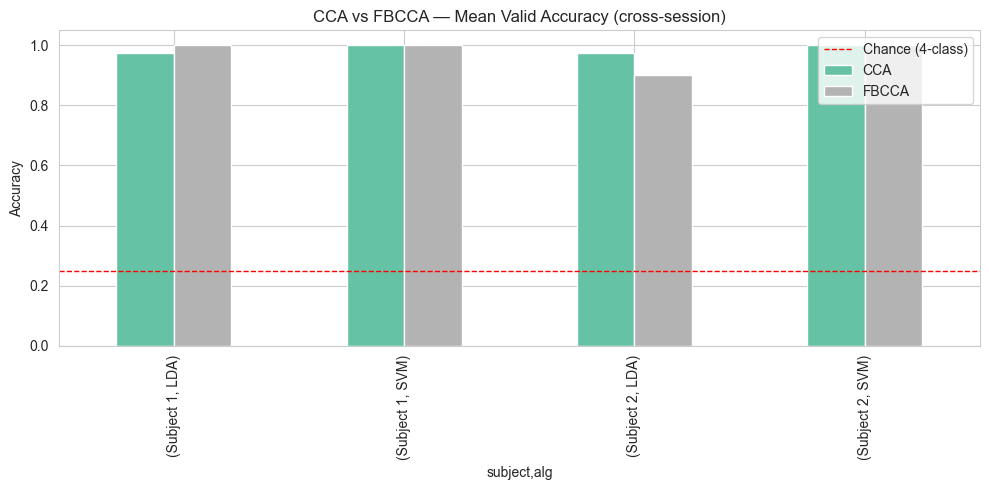

Saved → results/figures/cca_vs_fbcca.png


In [75]:
# ── CCA vs FBCCA: side-by-side valid_accuracy comparison ─────────────────
cca_rows  = results_df[results_df["feat"] == "CCA"].copy()
fbcca_rows = fbcca_df.copy()

compare = pd.concat([cca_rows, fbcca_rows], ignore_index=True)

pivot = (
    compare
    .groupby(["subject", "feat", "alg"])["valid_accuracy"]
    .mean()
    .unstack("feat")
    .round(3)
)
pivot["FBCCA_gain"] = (pivot.get("FBCCA", 0) - pivot.get("CCA", 0)).round(3)
display(pivot)

# Bar chart
ax = pivot[["CCA", "FBCCA"]].plot(
    kind="bar", figsize=(10, 5), colormap="Set2",
    title="CCA vs FBCCA — Mean Valid Accuracy (cross-session)"
)
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.05)
ax.axhline(0.25, color="red", linestyle="--", linewidth=1, label="Chance (4-class)")
ax.legend()
plt.tight_layout()
plt.savefig("../results/figures/cca_vs_fbcca.png", dpi=150)
plt.show()
print("Saved → results/figures/cca_vs_fbcca.png")
